# ST5011CEM Big Data Programming Project
# Samriddha Raj Satyal 
# CU ID: 15940432

# Arriva Merseyside Fare-Aware Service Reliability Audit
# Stakeholder: Transport Authority / Local Council Merseytravel / Liverpool City Region

---

### Reducing the unnnecessary warnings as it will look bad during coursework report submission:

In [1]:
import os
import warnings
import logging

# Hiding warnings coming from python
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

# To reduce all logs output
for logger in [
    "py4j",
    "py4j.clientserver",
    "pyspark",
    "matplotlib",
    "urllib3",
    "asyncio",
]:
    logging.getLogger(logger).setLevel(logging.ERROR)


java_opts = (
    "-Dlog4j2.rootLogger=ERROR,console "
    "-Dorg.slf4j.simpleLogger.defaultLogLevel=error"
)

existing = os.environ.get("JAVA_TOOL_OPTIONS", "")
os.environ["JAVA_TOOL_OPTIONS"] = f"{existing} {java_opts}".strip()

os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f'--driver-java-options "{java_opts}" '
    "--conf spark.ui.showConsoleProgress=false pyspark-shell",
)


def quiet_spark(spark):
    """Reduce Spark log output after creating the session."""
    try:
        spark.sparkContext.setLogLevel("ERROR")
    except Exception:
        pass
    return spark


print("Logging configured.")

Logging configured.


In [2]:
%matplotlib inline

from __future__ import annotations

import os
import sys
import re
import json
import time
import sqlite3
from pathlib import Path
from typing import Any, Iterable
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

sns.set_theme(style="whitegrid")

from IPython.display import display, Markdown, Image

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array


In [3]:
#opening project folder
CWD = Path.cwd().resolve()
if (CWD / "datasets").exists():
    PROJECT = CWD
elif (CWD.parent / "datasets").exists():
    PROJECT = CWD.parent
else:
    raise FileNotFoundError("Run from coursework/ — datasets/ not found")

In [4]:
#making the outputs and visuals folder because later it will be used for storing result and renaming folders
(PROJECT / "outputs").mkdir(parents=True, exist_ok=True)
(PROJECT / "visuals").mkdir(parents=True, exist_ok=True)
DATASETS = PROJECT / "datasets"
OUT = PROJECT / "outputs"
VIS = PROJECT / "visuals"
TIMETABLE_DIR = DATASETS / "timetable"
FARES_DIR = DATASETS / "fares"
LOCATION_DIR = DATASETS / "location"
DISRUPTIONS_COMBINED = DATASETS / "disruptions_processed" / "disruptions_combined.csv"
PROCESSED_DIR = OUT / "processed"
DATA_QUALITY_DIR = OUT / "data_quality"
DB_DIR = OUT / "db"
DB_PATH = DB_DIR / "merseyside_reliability_audit.sqlite"
RELIABILITY_DIR = OUT / "reliability"
FEATURES_DIR = OUT / "features"
DB_SCHEMA_DIR = OUT / "database_schema"
ML_DIR = OUT / "machine_learning"
DASHBOARD_EXPORTS_DIR = OUT / "dashboard_exports"
DATA_EXPLORATION_DIR = VIS / "data_exploration"

#defining the rules like compliance minutes, reliability threashold, min spark partitions, etc
URBAN_ONTIME_TOLERANCE_MINUTES = 2
SERVICE_RELIABILITY_THRESHOLD = 0.85
MIN_PARTITIONS = 4
NEAR_85_BAND = 0.10


In [5]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

#If required folders don't exist, this will create it
for p in [PROCESSED_DIR, DATA_QUALITY_DIR, DB_DIR, RELIABILITY_DIR, FEATURES_DIR, DB_SCHEMA_DIR,
          ML_DIR, DASHBOARD_EXPORTS_DIR,
          VIS / "reliability", VIS / "model_evaluation", VIS / "dashboard_charts",
          DATA_EXPLORATION_DIR, OUT / "visuals"]:
    p.mkdir(parents=True, exist_ok=True)
VIS_EXPORT_NAMES = ("reliability", "model_evaluation", "dashboard_charts")
_LEGACY_DIR_NAMES = (
    "phase2_phase3", "phase4", "phase5", "phase6", "phase7", "quality",
)

#removing previous outputs so that everytime notebook will start fresh
for name in _LEGACY_DIR_NAMES:
    for base in (OUT, VIS, OUT / "visuals"):
        legacy = base / name
        if legacy.is_dir():
            shutil.rmtree(legacy)


In [6]:
#creating the main spark session
def get_spark(app_name="Merseyside_Reliability_Audit"):
    spark = (
        SparkSession.builder.appName(app_name)
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.default.parallelism", "8")
        .config("spark.sql.files.maxPartitionBytes", str(64 * 1024 * 1024))
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.pyspark.python", sys.executable)
        .config("spark.pyspark.driver.python", sys.executable)
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    return spark

# save DataFrames as Spark-friendly Parquet files by standardising datetime columns
def write_parquet(df, path: Path):
    """Write Parquet with Spark-friendly microsecond, timezone-naive timestamps."""
    path.parent.mkdir(parents=True, exist_ok=True)
    out = df.copy()
    for col in out.columns:
        s = out[col]
        # timezone-aware → UTC naive
        if pd.api.types.is_datetime64tz_dtype(s):
            out[col] = s.dt.tz_convert("UTC").dt.tz_localize(None).astype("datetime64[us]")
        elif pd.api.types.is_datetime64_any_dtype(s) or str(s.dtype).startswith("datetime64"):
            out[col] = pd.to_datetime(s).astype("datetime64[us]")
    out.to_parquet(path, index=False)

# show chart in notebook AND save png for report
def show_and_save(fig, path: Path, dpi: int = 150):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path


# Phase 0 done
***


# Phase 1 — Ingest raw datasets

TxC, AVL, fares, disruptions → Parquet.


In [7]:
#Parsing timetables to parquet

#Without this line, later .find will not find anything
TXC_NS = {"txc": "http://www.transxchange.org.uk/"}

#smalll helper function to pull text from nested xml
def _text(el, path: str, default: str = "") -> str:
    if el is None:
        return default
    found = el.find(path, TXC_NS)
    return (found.text or default) if found is not None else default


#it will convert travel time in seconds
def _parse_runtime_to_seconds(runtime: str) -> int:
    """PT10M, PT1H5M, PT90S to seconds."""
    if not runtime:
        return 0
    hours = minutes = seconds = 0
    m = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", runtime)
    if not m:
        return 0
    hours = int(m.group(1) or 0)
    minutes = int(m.group(2) or 0)
    seconds = int(m.group(3) or 0)
    return hours * 3600 + minutes * 60 + seconds


#it will convert departure time to seconds since midnight
def _hhmmss_to_seconds(value: str) -> int | None:
    if not value:
        return None
    parts = value.strip().split(":")
    if len(parts) < 2:
        return None
    try:
        h, m = int(parts[0]), int(parts[1])
        s = int(parts[2]) if len(parts) > 2 else 0
        return h * 3600 + m * 60 + s
    except ValueError:
        return None


# this method will return stops, services, vehicle_journeys, schedule_events =
def parse_txc_file(path: Path) -> tuple[list[dict], list[dict], list[dict], list[dict]]:

    #loading the XML where root is the top element
    root = ET.parse(path).getroot()

    #this is for backup when XML is very large or like vague
    line_from_name = re.match(r"AMSY_([^_]+)_", path.name)
    file_line = line_from_name.group(1) if line_from_name else ""
    noc = _text(root, ".//txc:NationalOperatorCode")
    operator_name = _text(root, ".//txc:OperatorShortName")

    #now here we extract every bus stop mentioned in this file
    stops: list[dict] = []
    for sp in root.findall(".//txc:AnnotatedStopPointRef", TXC_NS):
        stops.append(
            {
                "source_file": path.name,
                "stop_id": _text(sp, "txc:StopPointRef"),
                "stop_name": _text(sp, "txc:CommonName"),
                "longitude": _text(sp, ".//txc:Longitude"),
                "latitude": _text(sp, ".//txc:Latitude"),
                "operator_noc": noc,
            }
        )

    #now here we extract every line metadata mentioned in this file
    services: list[dict] = []
    for svc in root.findall(".//txc:Service", TXC_NS):
        line_el = svc.find("txc:Lines/txc:Line", TXC_NS)
        services.append(
            {
                "source_file": path.name,
                "service_code": _text(svc, "txc:ServiceCode"),
                "line_name": _text(line_el, "txc:LineName") if line_el is not None else file_line,
                "line_id": line_el.get("id") if line_el is not None else "",
                "operator_noc": noc,
                "operator_name": operator_name,
            }
        )

    #now one route can have multiple links, so we will extract all the links for each journey pattern section and store it in a dictionary
    sections: dict[str, list[dict]] = {}
    for sec in root.findall(".//txc:JourneyPatternSection", TXC_NS):
        sid = sec.get("id") or ""
        links = []
        for link in sec.findall("txc:JourneyPatternTimingLink", TXC_NS):
            links.append(
                {
                    "from_stop": _text(link, "txc:From/txc:StopPointRef"),
                    "to_stop": _text(link, "txc:To/txc:StopPointRef"),
                    "runtime_sec": _parse_runtime_to_seconds(_text(link, "txc:RunTime")),
                }
            )
        sections[sid] = links


    #flattening the journey pattern into a list of stops with cumulative runtime and direction. cum_runtime_sec = seconds from journey start to each stop
    patterns: dict[str, list[dict]] = {}
    for jp in root.findall(".//txc:JourneyPattern", TXC_NS):
        jpid = jp.get("id") or ""
        direction = _text(jp, "txc:Direction")
        seq: list[dict] = []
        
        #total seconds from journey start to each stop
        cum = 0
        #first stop in the journey pattern, so we will set cum_runtime_sec to 0
        first = True 
        
        for ref in jp.findall(".//txc:JourneyPatternSectionRefs", TXC_NS):
            for link in sections.get(ref.text or "", []):
                #for first stop, cum_runtime_sec is 0, for others it will be cumulative sum of runtime_sec
                if first:
                    seq.append(
                        {
                            "stop_id": link["from_stop"],
                            "stop_sequence": 0,
                            "cum_runtime_sec": 0,
                            "direction": direction,
                        }
                    )
                    first = False
                cum += link["runtime_sec"]
                # each to_stop becomes next stop on the pattern
                seq.append(
                    {
                        "stop_id": link["to_stop"],
                        "stop_sequence": len(seq),
                        "cum_runtime_sec": cum,
                        "direction": direction,
                    }
                )
        patterns[jpid] = seq

    #now we extract every vehicle journey and schedule events mentioned in this file
    vehicle_journeys: list[dict] = []
    schedule_events: list[dict] = []

    for vj in root.findall(".//txc:VehicleJourney", TXC_NS):
        #which journey pattern this vehicle journey is following
        jp_ref = _text(vj, "txc:JourneyPatternRef")
        if not jp_ref:
            #sometimes the journey pattern ref is nested deeper, so we will check for that
            jp_ref = _text(vj, ".//txc:JourneyPatternRef")
        #then we extract the departure time, journey code, line reference and convert departure time to seconds since midnight
        dep = _text(vj, "txc:DepartureTime")
        journey_code = _text(vj, ".//txc:JourneyCode")
        line_ref = _text(vj, "txc:LineRef")
        dep_sec = _hhmmss_to_seconds(dep)

        #after this, we will append the vehicle journey  to their respective lists
        vehicle_journeys.append(
            {
                "source_file": path.name,
                "operator_noc": noc,
                "operator_name": operator_name,
                "line_name": file_line,
                "line_ref": line_ref,
                "journey_pattern_ref": jp_ref,
                "journey_code": journey_code,
                "departure_time": dep,
                "departure_seconds": dep_sec,
            }
        )

        #after this, we will append the schedule events to their respective lists
        for stop in patterns.get(jp_ref, []):
            aimed = None
            if dep_sec is not None:
                aimed = (dep_sec + stop["cum_runtime_sec"]) % (24 * 3600)
            schedule_events.append(
                {
                    "source_file": path.name,
                    "operator_noc": noc,
                    "line_name": file_line,
                    "journey_code": journey_code,
                    "journey_pattern_ref": jp_ref,
                    "direction": stop["direction"],
                    "stop_id": stop["stop_id"],
                    "stop_sequence": stop["stop_sequence"],
                    "departure_time": dep,
                    "aimed_arrival_seconds": aimed,
                    "cum_runtime_sec": stop["cum_runtime_sec"],
                }
            )

    #at last, we will return the stops, services, vehicle_journeys, schedule_events
    return stops, services, vehicle_journeys, schedule_events


#this method will ingest all the timetables and return a dictionary of structured Pandas dataframes
def ingest_timetables(timetable_dir: Path) -> dict[str, pd.DataFrame]:
    # First creating variables(lists) to store parsed data from all XML files
    stop_rows: list[dict] = []
    service_rows: list[dict] = []
    vj_rows: list[dict] = []
    event_rows: list[dict] = []

    #first, importing all arriva merseyside timetable files
    files = sorted(timetable_dir.glob("AMSY_*.xml"))
    for path in files:
        try:
            # Parsing individual TransXChange XML files into unique lists
            stops, services, vjs, events = parse_txc_file(path)
            stop_rows.extend(stops)
            service_rows.extend(services)
            vj_rows.extend(vjs)
            event_rows.extend(events)
        except ET.ParseError as exc:
            # Error handling and showing to user if corrupted file
            print(f"  WARN: skip {path.name}: {exc}")

    # Removing duplicates because some stops may be repeated across multiple files, and we want a unique list of stops
    stops_df = pd.DataFrame(stop_rows).drop_duplicates(subset=["stop_id", "source_file"])
    
    # Generating a unique master list of stops sorted by ID
    stop_master = (
        stops_df.sort_values(["stop_id"])
        .drop_duplicates(subset=["stop_id"], keep="first")
        .reset_index(drop=True)
    )

    # at last, we will return the stops, services, vehicle_journeys, schedule_events as a dictionary of Pandas DataFrames
    return {
        "timetable_stops": stop_master,
        "timetable_services": pd.DataFrame(service_rows),
        "timetable_vehicle_journeys": pd.DataFrame(vj_rows),
        "timetable_schedule_events": pd.DataFrame(event_rows),
    }

In [8]:
# Parsing ANWE SIRI-VM AVL snapshots into a flat vehicle-activity table
SIRI_NS = {"siri": "http://www.siri.org.uk/siri"}


# like _text for timetables but avl exports sometimes drop namespace prefix
def _findtext(el, path: str, default: str = "") -> str:
    found = el.find(path, SIRI_NS)
    if found is None:
        # try without ns (some exports omit default ns binding in find)
        found = el.find(path.replace("siri:", ""))
    return (found.text or default) if found is not None else default


# this method will parse the ANWE SIRI-VM AVL snapshots into a flat vehicle activity table
def parse_avl_file(path: Path) -> list[dict]:
    #stripping BOM / ensure parseable
    text = path.read_text(encoding="utf-8", errors="replace")
    root = ET.fromstring(text)

    rows: list[dict] = []
    #walking through the XML tree and extracting relevant information for each VehicleActivity element
    for va in root.iter():
        if not va.tag.endswith("VehicleActivity"):
            continue

        # generic tag finder anywhere under this activity
        def t(tag: str) -> str:
            for child in va.iter():
                if child.tag.endswith(tag) and child.text:
                    # Prefer first direct-ish match; for nested TicketMachine etc. still ok
                    return child.text
            return ""

        # More precise extraction for nested journey block
        mvj = None
        for child in va:
            if child.tag.endswith("MonitoredVehicleJourney"):
                mvj = child
                break

        # prefer searching inside mvj, fall back to whole activity if missing
        def mt(tag: str) -> str:
            if mvj is None:
                return t(tag)
            for child in mvj.iter():
                if child.tag.endswith(tag) and (child.text or "").strip():
                    return child.text.strip()
            return ""

        lon = mt("Longitude")
        lat = mt("Latitude")
        
        # one row = one snapshot of where a bus was and what trip it was on
        rows.append(
            {
                "source_file": path.name,
                "recorded_at_time": mt("RecordedAtTime") or t("RecordedAtTime"),
                "item_identifier": t("ItemIdentifier"),
                "line_ref": mt("LineRef"),
                "published_line_name": mt("PublishedLineName"),
                "direction_ref": mt("DirectionRef"),
                "operator_ref": mt("OperatorRef"),
                "origin_ref": mt("OriginRef"),
                "origin_name": mt("OriginName"),
                "destination_ref": mt("DestinationRef"),
                "destination_name": mt("DestinationName"),
                "origin_aimed_departure_time": mt("OriginAimedDepartureTime"),
                "destination_aimed_arrival_time": mt("DestinationAimedArrivalTime"),
                "dated_vehicle_journey_ref": mt("DatedVehicleJourneyRef"),
                "data_frame_ref": mt("DataFrameRef"),
                "vehicle_ref": mt("VehicleRef"),
                "block_ref": mt("BlockRef"),
                "bearing": mt("Bearing"),
                "longitude": float(lon) if lon else None,
                "latitude": float(lat) if lat else None,
                "journey_code": mt("JourneyCode"),
                "ticket_machine_service_code": mt("TicketMachineServiceCode"),
            }
        )
    return rows


def ingest_avl(location_dir: Path) -> pd.DataFrame:
    #searching for avl files in snapshots folder.
    files = sorted(location_dir.rglob("avl_709_*.xml"))
    all_rows: list[dict] = []
    for path in files:
        try:
            all_rows.extend(parse_avl_file(path))
        except ET.ParseError as exc:
            print(f"  WARN: skip {path.name}: {exc}")
    df = pd.DataFrame(all_rows)
    
    # force time columns to real datetimes — spark joins in phase 2-3 need this
    if not df.empty and "recorded_at_time" in df.columns:
        df["recorded_at_time"] = pd.to_datetime(df["recorded_at_time"], utc=True, errors="coerce")
        df["origin_aimed_departure_time"] = pd.to_datetime(
            df["origin_aimed_departure_time"], utc=True, errors="coerce"
        )
        df["destination_aimed_arrival_time"] = pd.to_datetime(
            df["destination_aimed_arrival_time"], utc=True, errors="coerce"
        )
    return df

In [9]:
# Parse AMSY NeTEx fares into a line-level fare proxy table

# helper to strip namespace from XML tag. For eg, if the tag is "{http://www.samriddha.com.uk/netex}Amount", it will return "Amount"
def _local(tag: str) -> str:
    return tag.split("}")[-1] if "}" in tag else tag


# this method will parse the AMSY NeTEx fares into a line-level fare proxy table
def parse_fare_file(path: Path) -> dict | None:
    try:
        root = ET.parse(path).getroot()
    except ET.ParseError:
        #skipping the file if it is corrupted or not a valid XML
        return None

    # Extract operator, line, and a representative fare amount if present
    text_head = path.read_text(encoding="utf-8", errors="replace")[:8000]
    noc_m = re.search(r'ref="noc:([^"]+)"', text_head)
    line_m = re.search(r"<PublicCode>([^<]+)</PublicCode>", text_head)
    desc_m = re.search(r"<Description>([^<]*Arriva[^<]*)</Description>", text_head)
    name_m = re.search(r"<Name>(Fares for Line[^<]*)</Name>", text_head)

    # Filename pattern: AMSY_{LINE}_...
    parts = path.name.split("_")
    line_from_file = parts[1] if len(parts) > 1 else ""

    # grab every amount in the file
    amounts: list[float] = []
    for el in root.iter():
        if _local(el.tag) in {"Amount", "DefaultAmount"} and el.text:
            try:
                amounts.append(float(el.text.strip()))
            except ValueError:
                continue

    
    amounts = [a for a in amounts if a > 0]
    if not amounts:
        fare_min = fare_max = fare_median = None
    else:
        amounts_sorted = sorted(amounts)
        fare_min = amounts_sorted[0]
        fare_max = amounts_sorted[-1]
        mid = len(amounts_sorted) // 2
        fare_median = amounts_sorted[mid]

    # Fare product hint from filename
    product_hint = ""
    upper = path.name.upper()
    if "ADSGL" in upper or "SGL" in upper:
        product_hint = "single"
    elif "ADRTN" in upper or "RTN" in upper:
        product_hint = "return"
    elif "DAY" in upper:
        product_hint = "day"
    elif "WK" in upper or "WEEK" in upper:
        product_hint = "week"
    else:
        product_hint = "other"

    #at last, we will return the parsed fare data as a dictionary
    return {
        "source_file": path.name,
        "operator_noc": noc_m.group(1) if noc_m else "AMSY",
        "line_name": line_from_file,
        "public_code": line_m.group(1) if line_m else line_from_file,
        "description": (desc_m.group(1) if desc_m else "")[:200],
        "fare_name": (name_m.group(1) if name_m else "")[:200],
        "product_hint": product_hint,
        "fare_amount_min": fare_min,
        "fare_amount_max": fare_max,
        "fare_amount_median": fare_median,
        "n_amount_values": len(amounts),
    }



### Returns:fare_files: one row per XML. fare_line_proxy: one row per line, with median/min/max fare and a proxy fare band

def ingest_fares(fares_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict] = []
    # Loop through all fares xml files in the fares directory, parse them, and collect the results
    for path in sorted(fares_dir.glob("AMSY_*.xml")):
        parsed = parse_fare_file(path)
        if parsed:
            rows.append(parsed)

    # Create a DataFrame from the parsed fare data
    files_df = pd.DataFrame(rows)
    # If no valid fare files were found, return empty DataFrames
    if files_df.empty:
        return files_df, files_df

    # Line-level proxy prefering single product medians when available
    singles = files_df[files_df["product_hint"] == "single"].copy()
    base = singles if not singles.empty else files_df

    # Aggregate fare statistics by line_name to create a proxy fare table
    proxy = (
        base.groupby("line_name", as_index=False)
        .agg(
            operator_noc=("operator_noc", "first"),
            fare_proxy_median=("fare_amount_median", "median"),
            fare_proxy_min=("fare_amount_min", "min"),
            fare_proxy_max=("fare_amount_max", "max"),
            n_fare_files=("source_file", "count"),
        )
        .sort_values("line_name")
        .reset_index(drop=True)
    )
    
    # Fallback band if all null
    proxy["fare_band"] = pd.cut(
        proxy["fare_proxy_median"].fillna(proxy["fare_proxy_median"].median()),
        bins=[-0.01, 2.0, 4.0, 7.0, 1e9],
        labels=["low", "medium", "high", "premium"],
    ).astype(str)

    return files_df, proxy

In [10]:
#This method will ingest disruptions from a CSV file and return a Pandas DataFrame with normalized boolean columns and datetime columns.
def ingest_disruptions(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Normalise booleans
    if "is_synthetic" in df.columns:
        df["is_synthetic"] = df["is_synthetic"].astype(str).str.lower().isin(["true", "1", "yes"])
    if "planned" in df.columns:
        df["planned"] = df["planned"].astype(str).str.lower().isin(["true", "1", "yes"])
    # Convert datetime columns to UTC-aware datetimes
    for col in ("validity_start", "validity_end", "publication_start", "publication_end"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
    return df

In [11]:
#This method will profile the pandas df and return dictionary
def profile_dataframe(name: str, df: pd.DataFrame) -> dict:
    
    #if the dataframe is None or empty, return a dictionary with zero counts and empty lists/dictionaries
    if df is None or df.empty:
        return {
            "table": name,
            "row_count": 0,
            "column_count": 0,
            "columns": [],
            "null_counts": {},
            "null_pct": {},
            "dtypes": {},
            "sample_nunique": {},
        }

    #Calculating null counts for each column in the dataframe
    null_counts = {c: int(df[c].isna().sum()) for c in df.columns}
    #Calculating the number of rows in the dataframe
    n = len(df) 
    
    return {
        "table": name,
        "row_count": int(n),
        "column_count": int(df.shape[1]),
        "columns": list(df.columns),
        "null_counts": null_counts,
        "null_pct": {c: round(null_counts[c] / n * 100, 2) if n else 0.0 for c in df.columns},
        "dtypes": {c: str(df[c].dtype) for c in df.columns},
        "sample_nunique": {
            c: int(df[c].nunique(dropna=True))
            for c in df.columns
            if df[c].dtype == object or str(df[c].dtype).startswith("string")
        },
    }

def write_quality_report(profiles: list[dict], out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    json_path = out_dir / "data_quality_report.json"
    md_path = out_dir / "data_quality_report.md"
    json_path.write_text(json.dumps(profiles, indent=2), encoding="utf-8")

    lines = ["# Data quality report", "", "After Phase 1 ingest.", ""]
    total = 0
    for p in profiles:
        total += p["row_count"]
        lines.append(f"## `{p['table']}` — {p['row_count']:,} rows")
        if p["row_count"]:
            top = sorted(p["null_pct"].items(), key=lambda x: -x[1])[:5]
            for col, pct in top:
                if pct > 0:
                    lines.append(f"- null `{col}`: {pct}%")
        lines.append("")
    sched = next((p for p in profiles if p["table"] == "timetable_schedule_events"), None)
    if sched and sched["row_count"] >= 100_000:
        lines.append(f"**Scale PASS:** schedule_events = {sched['row_count']:,} rows (>= 100k)")
    lines.append(f"**Combined rows:** {total:,}")
    md_path.write_text("\n".join(lines), encoding="utf-8")
    return md_path


In [12]:
# Recording the start time to measure the total execution time of the ingestion process.
t0 = time.time()


# Parsing timetable data into separate structured DataFrames.
tt = ingest_timetables(TIMETABLE_DIR)

# Saving each timetable DataFrame as a Parquet file.
for name, df in tt.items():
    write_parquet(df, PROCESSED_DIR / f"{name}.parquet")

    # Displaying the number of rows written for each timetable dataset.
    print(f"  {name}: {len(df):,} rows")


# Parsing all AVL XML files into a single DataFrame.
avl = ingest_avl(LOCATION_DIR)

# Saving the processed AVL data as a Parquet file.
write_parquet(avl, PROCESSED_DIR / "avl_vehicle_activities.parquet")

# Displaying the total number of AVL records processed.
print(f"  avl_vehicle_activities: {len(avl):,} rows")


# Extracting both the file-level fare data and the line-level fare proxy table.
fare_files, fare_proxy = ingest_fares(FARES_DIR)

# Saving both fare datasets as Parquet files.
write_parquet(fare_files, PROCESSED_DIR / "fares_files.parquet")
write_parquet(fare_proxy, PROCESSED_DIR / "fares_line_proxy.parquet")

# Displaying the number of records created for each fare dataset.
print(f"  fares_files: {len(fare_files):,} | fares_line_proxy: {len(fare_proxy):,}")


# Loading and cleaning the disruptions data.
disruptions = ingest_disruptions(DISRUPTIONS_COMBINED)

# Saving the processed disruptions dataset as a Parquet file.
write_parquet(disruptions, PROCESSED_DIR / "disruptions.parquet")

# Displaying the number of disruption records processed.
print(f"  disruptions: {len(disruptions):,}")


# Creating an empty list to store data quality profiles for every processed dataset.
profiles = []

# Generating a quality profile for each saved Parquet dataset.
for name in [
    "timetable_stops",
    "timetable_services",
    "timetable_vehicle_journeys",
    "timetable_schedule_events",
    "avl_vehicle_activities",
    "fares_files",
    "fares_line_proxy",
    "disruptions",
]:
    profiles.append(
        profile_dataframe(
            name,
            pd.read_parquet(PROCESSED_DIR / f"{name}.parquet")
        )
    )

# Saving the complete data quality report in JSON format.
write_quality_report(profiles, DATA_QUALITY_DIR)


# Displaying the total execution time for Phase 1.
print(f"\n Data ingestion completed in {time.time()-t0:.1f}s")

# Displaying the folder where all processed datasets have been stored.
print("Processed:", PROCESSED_DIR)


  timetable_stops: 4,870 rows
  timetable_services: 516 rows
  timetable_vehicle_journeys: 15,775 rows
  timetable_schedule_events: 769,705 rows
  avl_vehicle_activities: 279,198 rows
  fares_files: 861 | fares_line_proxy: 63
  disruptions: 2,025

 Data ingestion completed in 40.7s
Processed: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/processed


In [13]:
# readable quality summary in notebook
report_md = DATA_QUALITY_DIR / "data_quality_report.md"
if report_md.exists():
    display(Markdown(report_md.read_text(encoding="utf-8")))


# Data quality report

After Phase 1 ingest.

## `timetable_stops` — 4,870 rows

## `timetable_services` — 516 rows

## `timetable_vehicle_journeys` — 15,775 rows

## `timetable_schedule_events` — 769,705 rows

## `avl_vehicle_activities` — 279,198 rows
- null `origin_aimed_departure_time`: 13.67%
- null `destination_aimed_arrival_time`: 13.67%

## `fares_files` — 861 rows
- null `fare_amount_min`: 0.23%
- null `fare_amount_max`: 0.23%
- null `fare_amount_median`: 0.23%

## `fares_line_proxy` — 63 rows

## `disruptions` — 2,025 rows
- null `operator_noc`: 1.23%
- null `services_affected`: 1.23%
- null `stops_affected`: 1.23%
- null `stops_affected_names`: 1.23%
- null `expected_delay_minutes`: 1.23%

**Scale PASS:** schedule_events = 769,705 rows (>= 100k)
**Combined rows:** 1,073,013

timetable_schedule_events     769705
avl_vehicle_activities        279198
timetable_vehicle_journeys     15775
timetable_stops                 4870
disruptions                     2025
fares_files                      861
timetable_services               516
fares_line_proxy                  63


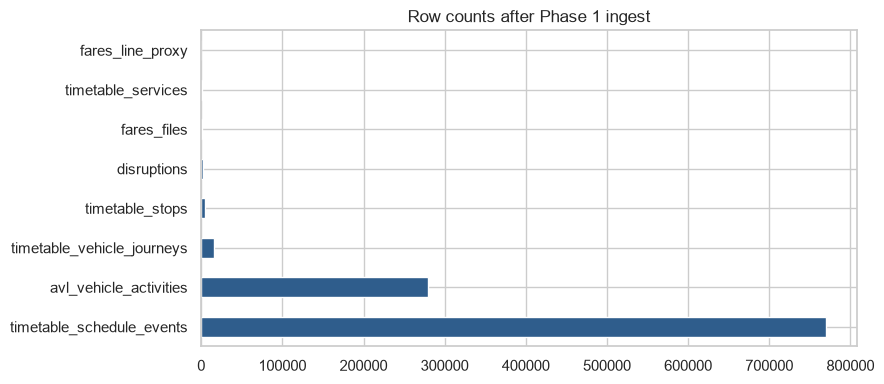

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/01_row_counts.png')

In [14]:
DATA_EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)
names = ["timetable_stops", "timetable_services", "timetable_vehicle_journeys",
         "timetable_schedule_events", "avl_vehicle_activities", "fares_files",
         "fares_line_proxy", "disruptions"]
counts = {n: len(pd.read_parquet(PROCESSED_DIR / f"{n}.parquet")) for n in names}
counts_s = pd.Series(counts).sort_values(ascending=False)
print(counts_s.to_string())
fig, ax = plt.subplots(figsize=(9, 4))
counts_s.plot(kind="barh", ax=ax, color="#2f5d8c")
ax.set_title("Row counts after Phase 1 ingest")
show_and_save(fig, DATA_EXPLORATION_DIR / "01_row_counts.png")


,n_journeys
line_name,
86A,1140
82,486
79,466
15,382
7,352
G10B,327
14,322
75,314
31,293


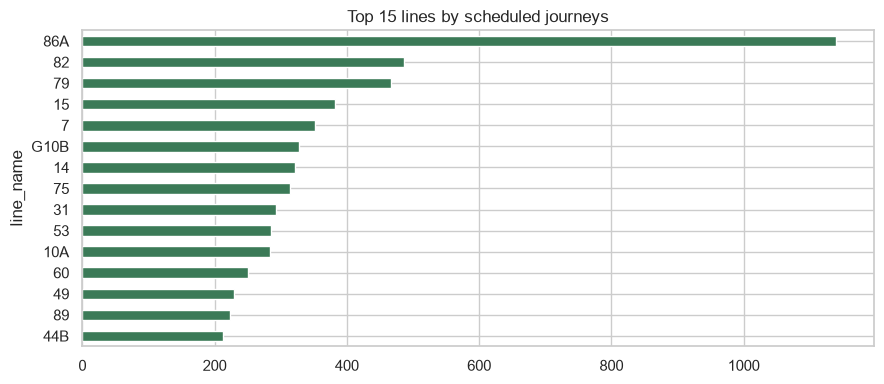

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/02_top_lines.png')

In [15]:
vj = pd.read_parquet(PROCESSED_DIR / "timetable_vehicle_journeys.parquet")
top_lines = vj["line_name"].value_counts().head(15)
display(top_lines.to_frame("n_journeys"))
fig, ax = plt.subplots(figsize=(9, 4))
top_lines.sort_values().plot(kind="barh", ax=ax, color="#3b7a57")
ax.set_title("Top 15 lines by scheduled journeys")
show_and_save(fig, DATA_EXPLORATION_DIR / "02_top_lines.png")


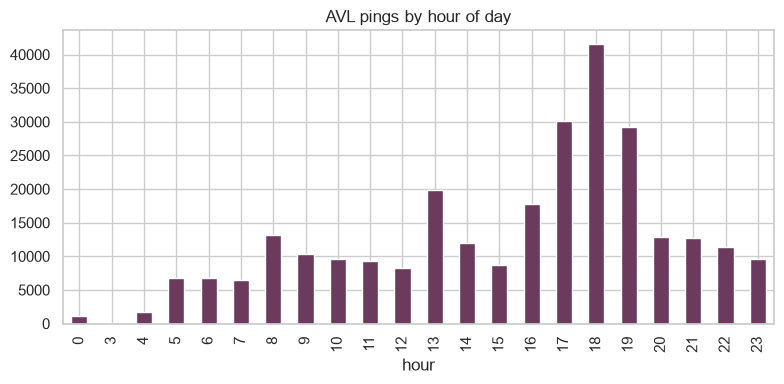

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/03_avl_by_hour.png')

In [16]:
avl_pdf = pd.read_parquet(PROCESSED_DIR / "avl_vehicle_activities.parquet")
avl_pdf["hour"] = pd.to_datetime(avl_pdf["recorded_at_time"]).dt.hour
by_hour = avl_pdf["hour"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
by_hour.plot(kind="bar", ax=ax, color="#6b3a5d")
ax.set_title("AVL pings by hour of day")
show_and_save(fig, DATA_EXPLORATION_DIR / "03_avl_by_hour.png")


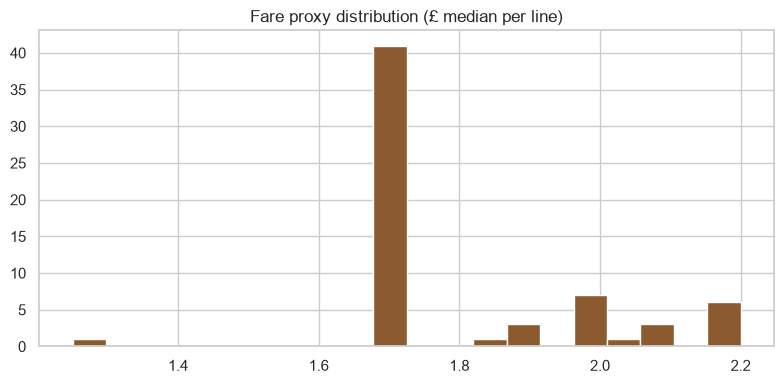

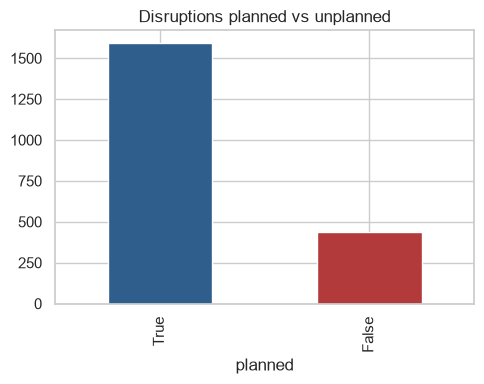

In [17]:
proxy = pd.read_parquet(PROCESSED_DIR / "fares_line_proxy.parquet")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(proxy["fare_proxy_median"].dropna(), bins=20, color="#8c5a2f")
ax.set_title("Fare proxy distribution (£ median per line)")
show_and_save(fig, DATA_EXPLORATION_DIR / "04_fare_proxy.png")

dis = pd.read_parquet(PROCESSED_DIR / "disruptions.parquet")
if "planned" in dis.columns:
    fig, ax = plt.subplots(figsize=(5, 4))
    dis["planned"].value_counts().plot(kind="bar", ax=ax, color=["#2f5d8c", "#b33a3a"])
    ax.set_title("Disruptions planned vs unplanned")
    show_and_save(fig, DATA_EXPLORATION_DIR / "05_disruptions.png")


# Phase 1 complete
***


# Phase 2 — Spark load & Big Data proof

Repartition >=4, cache, broadcast join.


In [18]:
#This function will convert timestamps so that spark can ingest it
def _spark_safe_pandas(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    
    # Iterating through all columns to identify datetime fields.
    for c in out.columns:
        # Checking whether the current column contains datetime values.
        if pd.api.types.is_datetime64_any_dtype(out[c]) or str(out[c].dtype).startswith(
            "datetime64"
        ):
            s = out[c]
            # Converting timezone-aware timestamps into UTC and removing timezone information.
            if getattr(s.dtype, "tz", None) is not None:
                s = s.dt.tz_convert("UTC").dt.tz_localize(None)
            # Converting timestamps into microsecond precision for Spark compatibility.
            out[c] = pd.to_datetime(s).astype("datetime64[us]")

    return out


#it is fallback to pandas to spark.
def _read_parquet(spark: SparkSession, path: Path) -> DataFrame:
    try:
        # Reading the Parquet file directly using Spark whenever possible.
        return spark.read.parquet(str(path))
    except Exception:

        # Falling back to pandas when Spark cannot read nanosecond timestamps.
        pdf = _spark_safe_pandas(pd.read_parquet(path))

        # Creating a Spark DataFrame from the converted pandas DataFrame.
        return spark.createDataFrame(pdf)

In [19]:
# Loading all processed datasets into Spark DataFrames.
def load_processed_tables(spark: SparkSession) -> dict[str, DataFrame]:
    base = Path(PROCESSED_DIR)
    tables = {
        "schedule_events": _read_parquet(spark, base / "timetable_schedule_events.parquet"),
        "vehicle_journeys": _read_parquet(spark, base / "timetable_vehicle_journeys.parquet"),
        "stops": _read_parquet(spark, base / "timetable_stops.parquet"),
        "services": _read_parquet(spark, base / "timetable_services.parquet"),
        "avl": _read_parquet(spark, base / "avl_vehicle_activities.parquet"),
        "fares_proxy": _read_parquet(spark, base / "fares_line_proxy.parquet"),
        "disruptions": _read_parquet(spark, base / "disruptions.parquet"),
    }
    return tables

In [20]:
# Mandatory Big Data evidence: >=4 partitions + cache large tables
def spark_proof_repartition_cache(
    tables: dict[str, DataFrame], n_parts: int = 8
) -> dict[str, DataFrame]:
    # Verifying that the requested partition count satisfies the minimum requirement.
    assert n_parts >= MIN_PARTITIONS

    out = {}

    # Processing each dataset to optimise partitioning and caching.
    for name, df in tables.items():

        # Repartitioning large datasets for better parallel processing.
        if name in {"schedule_events", "avl", "disruptions"}:
            df2 = df.repartition(n_parts)
        else:

            # Repartitioning smaller datasets while keeping at least the minimum partitions.
            df2 = df.repartition(max(MIN_PARTITIONS, min(n_parts, 4)))

        # Caching the repartitioned DataFrame to improve repeated access.
        df2 = df2.cache()

        # Materialising the cache so Spark executes the transformations immediately.
        _ = df2.count()

        out[name] = df2

    return out

In [21]:
def partition_report(tables: dict[str, DataFrame]) -> list[dict]:
    rows = []

    # Collecting partition and row count statistics for each dataset.
    for name, df in tables.items():
        rows.append(
            {
                "table": name,
                "row_count": df.count(),
                "num_partitions": df.rdd.getNumPartitions(),
            }
        )

    return rows

Spark UI: http://macbookair:4040


,table,row_count,num_partitions
0,schedule_events,769705,8
1,vehicle_journeys,15775,4
2,stops,4870,4
3,services,516,4
4,avl,279198,8
5,fares_proxy,63,4
6,disruptions,2025,8


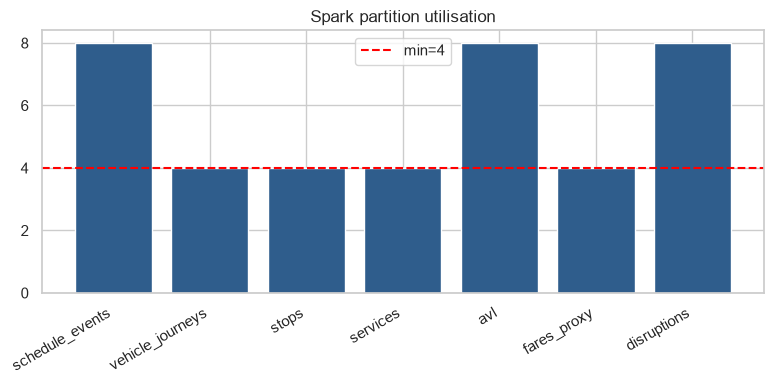

Broadcast demo lines: 200 fare matches: 62


In [23]:
# Creating a Spark session for the Phase 2 analysis.
spark = quiet_spark(get_spark("Phase2_Spark_Lab"))

# Displaying the Spark UI link for monitoring jobs and execution.
print("Spark UI:", spark.sparkContext.uiWebUrl)

# Loading all processed datasets into Spark.
tables = load_processed_tables(spark)

# Repartitioning and caching the datasets for distributed processing.
tables = spark_proof_repartition_cache(tables, n_parts=8)

# Generating a summary of partition utilisation across all datasets.
part_df = pd.DataFrame(partition_report(tables))

# Saving the partition summary for reproducibility and reporting.
part_df.to_csv(RELIABILITY_DIR / "partition_utilisation.csv", index=False)

# Displaying the partition summary table.
display(part_df)

# Creating a chart to visualise partition utilisation.
fig, ax = plt.subplots(figsize=(8, 4))

# Plotting the number of partitions for each dataset.
ax.bar(part_df["table"], part_df["num_partitions"], color="#2f5d8c")

# Highlighting the minimum required partition threshold.
ax.axhline(MIN_PARTITIONS, color="red", linestyle="--", label="min=4")

ax.set_title("Spark partition utilisation")
ax.legend()
plt.xticks(rotation=30, ha="right")

# Displaying and saving the partition utilisation chart.
show_and_save(fig, VIS / "reliability" / "spark_partition_utilisation.png")

# Aggregating schedule events by route to prepare for the broadcast join.
sched_lines = (
    tables["schedule_events"]
    .withColumn("line_key", F.upper(F.trim(F.col("line_name"))))
    .groupBy("line_key")
    .count()
)

# Broadcasting the smaller fares dataset to optimise the join operation.
fares_b = broadcast(
    tables["fares_proxy"]
    .withColumn("line_key", F.upper(F.trim(F.col("line_name"))))
)

# Joining schedule counts with fare information using the broadcast dataset.
demo = sched_lines.join(fares_b, on="line_key", how="left")

# Displaying the number of matched routes after the broadcast join.
print(
    "Broadcast demo lines:",
    sched_lines.count(),
    "fare matches:",
    demo.filter(F.col("fare_proxy_median").isNotNull()).count(),
)

## Phase 2 — Spark SQL peek


In [25]:
# Register large / useful tables as temp views (like CREATE TEMP VIEW in labs)
tables["schedule_events"].createOrReplaceTempView("schedule_events")
tables["avl"].createOrReplaceTempView("avl")
tables["fares_proxy"].createOrReplaceTempView("fares_proxy")
tables["disruptions"].createOrReplaceTempView("disruptions")
tables["vehicle_journeys"].createOrReplaceTempView("vehicle_journeys")

print("Temp views registered. Example Spark SQL queries:\n")

# 1) Count + top lines by schedule events
spark.sql("SELECT COUNT(*) AS n_schedule_events FROM schedule_events").show()

spark.sql(
    """
    SELECT line_name, COUNT(*) AS n_events
    FROM schedule_events
    GROUP BY line_name
    ORDER BY n_events DESC
    LIMIT 10
    """
).show(truncate=False)

# 2) AVL summary by line
spark.sql(
    """
    SELECT
        UPPER(TRIM(COALESCE(published_line_name, line_ref))) AS line_key,
        COUNT(*) AS n_pings,
        COUNT(DISTINCT vehicle_ref) AS n_vehicles
    FROM avl
    GROUP BY UPPER(TRIM(COALESCE(published_line_name, line_ref)))
    ORDER BY n_pings DESC
    LIMIT 10
    """
).show(truncate=False)

# 3) SQL join — schedule lines left-join fare proxy (same idea as broadcast demo)
spark.sql(
    """
    SELECT
        s.line_key,
        s.n_events,
        f.fare_proxy_median,
        f.fare_band
    FROM (
        SELECT UPPER(TRIM(line_name)) AS line_key, COUNT(*) AS n_events
        FROM schedule_events
        GROUP BY UPPER(TRIM(line_name))
    ) s
    LEFT JOIN (
        SELECT UPPER(TRIM(line_name)) AS line_key, fare_proxy_median, fare_band
        FROM fares_proxy
    ) f
    ON s.line_key = f.line_key
    ORDER BY s.n_events DESC
    LIMIT 15
    """
).show(truncate=False)

Temp views registered. Example Spark SQL queries:

+-----------------+
|n_schedule_events|
+-----------------+
|           769705|
+-----------------+

+---------+--------+
|line_name|n_events|
+---------+--------+
|86A      |50942   |
|7        |28658   |
|82       |24543   |
|79       |20649   |
|10A      |18942   |
|89       |17347   |
|75       |14601   |
|47       |14569   |
|44       |13232   |
|G10B     |13042   |
+---------+--------+

+--------+-------+----------+
|line_key|n_pings|n_vehicles|
+--------+-------+----------+
|79C     |59150  |36        |
|82A     |46613  |34        |
|TRG     |26884  |12        |
|61      |25532  |26        |
|110     |24081  |20        |
|X4      |16013  |8         |
|X30     |15049  |17        |
|P5      |13885  |15        |
|2       |11171  |11        |
|1       |9518   |12        |
+--------+-------+----------+

+--------+--------+-----------------+---------+
|line_key|n_events|fare_proxy_median|fare_band|
+--------+--------+-----------------

# Phase 2 complete
***


# Phase 3 — Label journeys & reliability

±2 min compliance → analytical_journeys.parquet


In [26]:
# This method will group thousands of pings per journey into one single row per journey, with a delay proxy and other journey-level fields.
def build_journey_grain(avl: DataFrame) -> DataFrame:
    # Creating a unique key for each journey by combining operator, line, dated vehicle journey, data frame, and vehicle references.
    avl_n = avl.withColumn(
        "line_key",
        F.upper(F.trim(F.coalesce(F.col("published_line_name"), F.col("line_ref")))),
    ).withColumn(
        "journey_key",
        F.concat_ws(
            "|",
            F.coalesce(F.col("operator_ref"), F.lit("UNK")),
            F.col("line_key"),
            F.coalesce(F.col("dated_vehicle_journey_ref"), F.lit("NA")),
            F.coalesce(F.col("data_frame_ref"), F.lit("NA")),
            F.coalesce(F.col("vehicle_ref"), F.lit("NA")),
        ),
    )

    #Now, filtering those pings that have both recorded_at_time and origin_aimed_departure_time, and calculating the absolute departure delta in minutes for each ping.
    usable = avl_n.filter(
        F.col("recorded_at_time").isNotNull() & F.col("origin_aimed_departure_time").isNotNull()
    ).withColumn(
        "abs_dep_delta_min",
        F.abs(
            (
                F.unix_timestamp(F.col("recorded_at_time"))
                - F.unix_timestamp(F.col("origin_aimed_departure_time"))
            )
            / 60.0
        ),
    )

    # Filtering pings that are within 45 minutes of the scheduled departure time to identify near-departure observations.
    near_dep = usable.filter(F.col("abs_dep_delta_min") <= F.lit(45.0))
    # if no near-departure ping, keeping closest overall
    w_near = Window.partitionBy("journey_key").orderBy(F.col("abs_dep_delta_min").asc())
    picked_near = near_dep.withColumn("rn", F.row_number().over(w_near)).filter(F.col("rn") == 1)

    w_all = Window.partitionBy("journey_key").orderBy(F.col("abs_dep_delta_min").asc())
    picked_all = usable.withColumn("rn", F.row_number().over(w_all)).filter(F.col("rn") == 1)

    # Joining the picked near-departure pings with the picked overall pings to create a single row per journey
    journeys = (
        picked_all.alias("a")
        .join(picked_near.alias("n"), on="journey_key", how="left")
        .select(
            F.col("journey_key"),
            F.coalesce(F.col("n.recorded_at_time"), F.col("a.recorded_at_time")).alias(
                "first_recorded_at"
            ),
            F.coalesce(
                F.col("n.origin_aimed_departure_time"), F.col("a.origin_aimed_departure_time")
            ).alias("origin_aimed_departure_time"),
            F.coalesce(
                F.col("n.destination_aimed_arrival_time"),
                F.col("a.destination_aimed_arrival_time"),
            ).alias("destination_aimed_arrival_time"),
            F.coalesce(F.col("n.operator_ref"), F.col("a.operator_ref")).alias("operator_ref"),
            F.coalesce(F.col("n.line_key"), F.col("a.line_key")).alias("line_key"),
            F.coalesce(F.col("n.line_ref"), F.col("a.line_ref")).alias("line_ref"),
            F.coalesce(F.col("n.published_line_name"), F.col("a.published_line_name")).alias(
                "published_line_name"
            ),
            F.coalesce(F.col("n.direction_ref"), F.col("a.direction_ref")).alias("direction_ref"),
            F.coalesce(F.col("n.origin_ref"), F.col("a.origin_ref")).alias("origin_ref"),
            F.coalesce(F.col("n.origin_name"), F.col("a.origin_name")).alias("origin_name"),
            F.coalesce(F.col("n.destination_ref"), F.col("a.destination_ref")).alias(
                "destination_ref"
            ),
            F.coalesce(F.col("n.destination_name"), F.col("a.destination_name")).alias(
                "destination_name"
            ),
            F.coalesce(
                F.col("n.dated_vehicle_journey_ref"), F.col("a.dated_vehicle_journey_ref")
            ).alias("dated_vehicle_journey_ref"),
            F.coalesce(F.col("n.data_frame_ref"), F.col("a.data_frame_ref")).alias("data_frame_ref"),
            F.coalesce(F.col("n.vehicle_ref"), F.col("a.vehicle_ref")).alias("vehicle_ref"),
            F.coalesce(F.col("n.journey_code"), F.col("a.journey_code")).alias("journey_code"),
            F.coalesce(
                F.col("n.ticket_machine_service_code"), F.col("a.ticket_machine_service_code")
            ).alias("ticket_machine_service_code"),
            F.coalesce(F.col("n.longitude"), F.col("a.longitude")).alias("longitude"),
            F.coalesce(F.col("n.latitude"), F.col("a.latitude")).alias("latitude"),
            F.when(F.col("n.journey_key").isNotNull(), F.lit(1))
            .otherwise(F.lit(0))
            .alias("used_near_departure_ping"),
        )
    )

    # Calculating the number of pings for each journey to provide context on data density.
    n_obs = usable.groupBy("journey_key").agg(F.count("*").alias("n_obs"))
    journeys = journeys.join(n_obs, on="journey_key", how="left")

    # Keeping last ping coords for context
    w_last = Window.partitionBy("journey_key").orderBy(F.col("recorded_at_time").desc())
    last_ping = (
        usable.withColumn("rn_last", F.row_number().over(w_last))
        .filter(F.col("rn_last") == 1)
        .select(
            "journey_key",
            F.col("recorded_at_time").alias("last_recorded_at"),
            F.col("longitude").alias("last_longitude"),
            F.col("latitude").alias("last_latitude"),
        )
    )
    journeys = journeys.join(last_ping, on="journey_key", how="left")

    journeys = journeys.withColumn(
        "delay_minutes",
        (
            F.unix_timestamp(F.col("first_recorded_at"))
            - F.unix_timestamp(F.col("origin_aimed_departure_time"))
        )
        / 60.0,
    ).withColumn(
        "scheduled_trip_minutes",
        (
            F.unix_timestamp(F.col("destination_aimed_arrival_time"))
            - F.unix_timestamp(F.col("origin_aimed_departure_time"))
        )
        / 60.0,
    )

    journeys = (
        journeys.withColumn("event_date", F.to_date("origin_aimed_departure_time"))
        .withColumn("hour_of_day", F.hour("origin_aimed_departure_time"))
        .withColumn("day_of_week", F.dayofweek("origin_aimed_departure_time"))
        .withColumn(
            "is_peak",
            F.when(
                (F.col("hour_of_day").between(7, 9)) | (F.col("hour_of_day").between(16, 18)),
                F.lit(1),
            ).otherwise(F.lit(0)),
        )
    )

    # Adding a compliance value based on the absolute delay compared to the defined tolerance.
    tol = float(URBAN_ONTIME_TOLERANCE_MINUTES)
    journeys = journeys.withColumn(
        "is_compliant",
        F.when(F.abs(F.col("delay_minutes")) <= F.lit(tol), F.lit(1)).otherwise(F.lit(0)),
    ).withColumn(
        "compliance_rule",
        F.lit(f"urban_abs_delay_le_{URBAN_ONTIME_TOLERANCE_MINUTES}_min"),
    )

    return journeys


In [27]:
# attaching timetable per journey
def attach_txc_context(journeys: DataFrame, vehicle_journeys: DataFrame) -> DataFrame:
    txc_lines = (
        vehicle_journeys.withColumn("line_key", F.upper(F.trim(F.col("line_name"))))
        .groupBy("line_key")
        .agg(
            F.countDistinct("journey_code").alias("txc_n_journey_codes"),
            F.count("*").alias("txc_n_vehicle_journeys"),
            F.first("operator_noc").alias("txc_operator_noc"),
            F.first("operator_name").alias("txc_operator_name"),
        )
    )

    out = journeys.join(broadcast(txc_lines), on="line_key", how="left")
    out = out.withColumn(
        "has_txc_line_match",
        F.when(F.col("txc_operator_noc").isNotNull(), F.lit(1)).otherwise(F.lit(0)),
    ).withColumn(
        "noc_alignment_note",
        F.when(
            F.col("has_txc_line_match") == 1,
            F.lit("ANWE_AVL_line_matched_AMSY_timetable_line"),
        ).otherwise(
            F.lit("ANWE_AVL_line_without_AMSY_timetable_match_delay_from_SIRI_aimed_times")
        ),
    )
    return out

In [28]:
#Attaching fare weight per journey for fare exposure
def attach_fares(journeys: DataFrame, fares_proxy: DataFrame) -> DataFrame:
    fares = fares_proxy.withColumn("line_key", F.upper(F.trim(F.col("line_name")))).select(
        "line_key",
        F.col("fare_proxy_median").alias("fare_proxy_line"),
        F.col("fare_band").alias("fare_band_line"),
        F.col("operator_noc").alias("fare_operator_noc"),
    )
    network_median = fares_proxy.agg(
        F.avg("fare_proxy_median").alias("fare_proxy_network")
    ).collect()[0][0]

    out = journeys.join(broadcast(fares), on="line_key", how="left")

    # fare_proxy = line match if possible, else network median
    # fare_proxy_source tells the report which path was used
    out = (
        out.withColumn(
            "has_fare_match",
            F.when(F.col("fare_proxy_line").isNotNull(), F.lit(1)).otherwise(F.lit(0)),
        )
        .withColumn(
            "fare_proxy",
            F.coalesce(F.col("fare_proxy_line"), F.lit(float(network_median or 0.0))),
        )
        .withColumn(
            "fare_band",
            F.coalesce(F.col("fare_band_line"), F.lit("network_default")),
        )
        .withColumn(
            "fare_proxy_source",
            F.when(F.col("has_fare_match") == 1, F.lit("amsy_line_match")).otherwise(
                F.lit("amsy_network_median_fallback_for_anwe_lines")
            ),
        )
    )
    return out

In [29]:
# This method will attach disruption pressure features to the journeys DataFrame based on line and time overlap with the disruptions DataFrame.
def attach_disruptions(journeys: DataFrame, disruptions: DataFrame) -> DataFrame:
    dis = (
        disruptions.withColumn(
            "service_line",
            F.explode_outer(F.split(F.coalesce(F.col("services_affected"), F.lit("")), ";")),
        )
        .withColumn("line_key", F.upper(F.trim(F.col("service_line"))))
        .filter(F.col("line_key") != "")
        .select(
            "line_key",
            "reason",
            "severity",
            "planned",
            "is_synthetic",
            "expected_delay_minutes",
            F.col("validity_start").alias("dis_start"),
            F.col("validity_end").alias("dis_end"),
        )
    )

    # Joining the journeys with the disruptions based on the line key and time overlap
    joined = journeys.join(dis, on="line_key", how="left")

    overlapped = joined.filter(
        F.col("dis_start").isNull()
        | (
            (F.col("origin_aimed_departure_time") >= F.col("dis_start"))
            & (
                F.col("dis_end").isNull()
                | (F.col("origin_aimed_departure_time") <= F.col("dis_end"))
            )
        )
    )

    severity_weight = (
        F.when(F.col("severity") == "severe", 3.0)
        .when(F.col("severity") == "moderate", 2.0)
        .when(F.col("severity") == "minor", 1.0)
        .otherwise(0.0)
    )

    agg = overlapped.groupBy("journey_key").agg(
        F.sum(severity_weight).alias("disruption_severity_score"),
        F.count(F.when(F.col("reason").isNotNull(), 1)).alias("n_disruption_matches"),
        F.max(F.when(F.col("planned") == True, 1).otherwise(0)).alias("had_planned_disruption"),
        F.max(F.when(F.col("is_synthetic") == False, 1).otherwise(0)).alias(
            "had_real_merseytravel_disruption"
        ),
        F.first("reason", ignorenulls=True).alias("primary_disruption_reason"),
        F.first("severity", ignorenulls=True).alias("primary_disruption_severity"),
        F.avg("expected_delay_minutes").alias("disruption_expected_delay_avg"),
    )

    out = journeys.join(agg, on="journey_key", how="left")
    out = (
        out.fillna(
            {
                "disruption_severity_score": 0.0,
                "n_disruption_matches": 0,
                "had_planned_disruption": 0,
                "had_real_merseytravel_disruption": 0,
            }
        )
        .withColumn(
            "has_disruption",
            F.when(F.col("n_disruption_matches") > 0, F.lit(1)).otherwise(F.lit(0)),
        )
    )
    return out

In [30]:
# This method will compute service reliability aggregates for the journeys DataFrame
def service_reliability_aggregates(journeys: DataFrame) -> dict[str, DataFrame]:
    # Defining the threshold for service reliability below which a service is considered non-compliant.
    thr = float(SERVICE_RELIABILITY_THRESHOLD)

    #This inner function will do the actual grouping and aggregating
    def _agg(group_cols: list[str], name: str) -> DataFrame:
        g = (
            journeys.groupBy(*group_cols)
            .agg(
                F.count("*").alias("n_journeys"),
                F.sum("is_compliant").alias("n_compliant"),
                F.avg("delay_minutes").alias("avg_delay_minutes"),
                F.stddev("delay_minutes").alias("std_delay_minutes"),
            )
            .withColumn(
                "service_reliability",
                F.col("n_compliant") / F.col("n_journeys"),
            )
            .withColumn(
                "below_85_threshold",
                F.when(F.col("service_reliability") < F.lit(thr), F.lit(1)).otherwise(F.lit(0)),
            )
        )
        return g

    return {
        "reliability_by_line": _agg(["line_key", "operator_ref"], "line"),
        "reliability_by_hour": _agg(["hour_of_day"], "hour"),
        "reliability_by_day": _agg(["event_date"], "day"),
        "reliability_by_line_hour": _agg(["line_key", "hour_of_day"], "line_hour"),
    }


In [31]:
# This method will add fare exposure weights to the journeys DataFrame for later testing, based on fare proxies and compliance status.
def add_exposure_placeholder(journeys: DataFrame) -> DataFrame:
    return (
        journeys.withColumn(
            "observed_fare_exposure",
            F.when(
                (F.col("is_compliant") == 0) & F.col("fare_proxy").isNotNull(),
                F.col("fare_proxy"),
            ).otherwise(F.lit(0.0)),
        )
        .withColumn(
            "hypothetical_exposure_note",
            F.lit("fare_proxy_x_noncompliance_for_authority_scenario_not_real_DfT_fine"),
        )
    )


Funnel: AVL=279,198 -> journey_grain=1,421 -> labelled=1,421
+------------+-----+
|is_compliant|count|
+------------+-----+
|           1|  817|
|           0|  604|
+------------+-----+

reliability_by_line 17
reliability_by_hour 21
reliability_by_day 8
reliability_by_line_hour 170
Saved analytical_journeys (1421, 56) compliance= 0.575


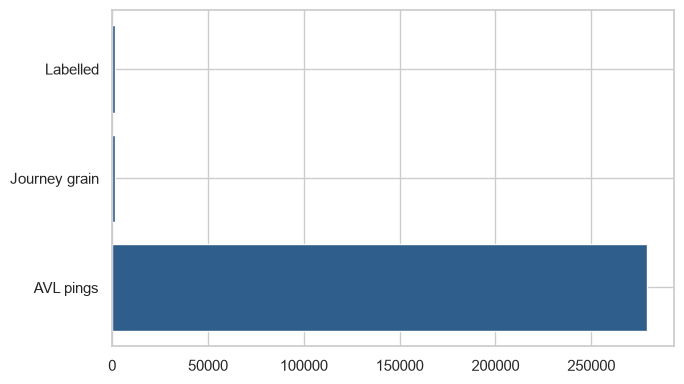

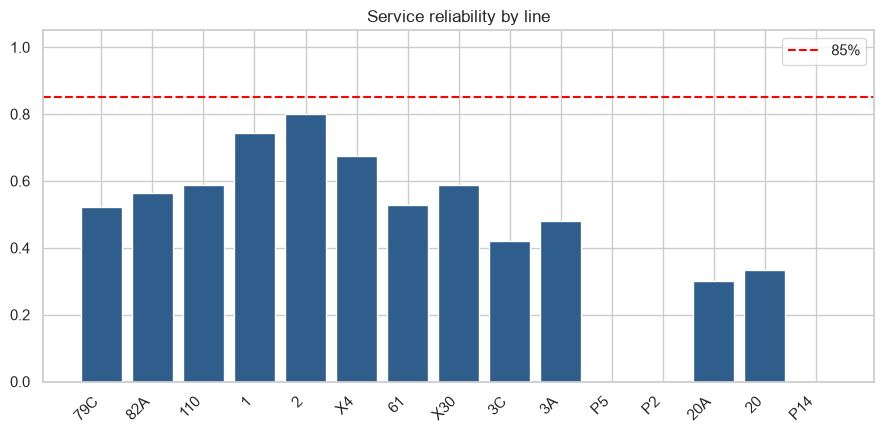

,journey_key,line_key,first_recorded_at,origin_aimed_departure_time,destination_aimed_arrival_time,operator_ref,line_ref,published_line_name,direction_ref,origin_ref,...,disruption_severity_score,n_disruption_matches,had_planned_disruption,had_real_merseytravel_disruption,primary_disruption_reason,primary_disruption_severity,disruption_expected_delay_avg,has_disruption,observed_fare_exposure,hypothetical_exposure_note
0,ANWE|110|1001|2026-06-16|3020,110,2026-06-16 03:56:50,2026-06-16 03:57:00,2026-06-16 04:57:00,ANWE,110,110,outbound,068000000063,...,0.0,0,0,0,None,None,NaN,0,0.000000,fare_proxy_x_noncompliance_for_authority_scena...
1,ANWE|110|1003|2026-06-15|3177,110,2026-06-15 04:19:23,2026-06-15 04:20:00,2026-06-15 05:24:00,ANWE,110,110,outbound,068000000063,...,0.0,0,0,0,None,None,NaN,0,0.000000,fare_proxy_x_noncompliance_for_authority_scena...
2,ANWE|110|1007|2026-06-15|3018,110,2026-06-15 05:32:09,2026-06-15 05:30:00,2026-06-15 06:35:00,ANWE,110,110,outbound,068000000063,...,0.0,0,0,0,None,None,NaN,0,1.810317,fare_proxy_x_noncompliance_for_authority_scena...
3,ANWE|110|1008|2026-06-16|3136,110,2026-06-16 06:44:52,2026-06-16 06:45:00,2026-06-16 07:46:00,ANWE,110,110,inbound,0690WNA02861,...,2.0,1,1,0,roadworks,moderate,18.0,1,0.000000,fare_proxy_x_noncompliance_for_authority_scena...
4,ANWE|110|1014|2026-06-16|3159,110,2026-06-16 08:25:01,2026-06-16 08:25:00,2026-06-16 09:25:00,ANWE,110,110,inbound,0690WNA02861,...,2.0,1,1,0,roadworks,moderate,18.0,1,0.000000,fare_proxy_x_noncompliance_for_authority_scena...


In [32]:
# Counting records before starting Phase 3 so that we can later show
# how the data size changes through each processing stage
n_avl = tables["avl"].count()
n_sched = tables["schedule_events"].count()


# Converting thousands of AVL GPS pings into one row per bus journey.
journeys = build_journey_grain(tables["avl"])
n_grain = journeys.count()


# Joining timetable information (TxC) such as journey codes and line details
journeys = attach_txc_context(journeys, tables["vehicle_journeys"])


# Adding fare information for each line.
# If an exact fare is unavailable, the helper function automatically
# uses the network median fare as a fallback.
journeys = attach_fares(journeys, tables["fares_proxy"])


# Checking whether each journey overlaps with any disruption event
journeys = attach_disruptions(journeys, tables["disruptions"])


# Adding an exposure placeholder value which will later be used
# during risk calculations in the ML and dashboard phases
# Cache() keeps this important table in memory because it will be reused multiple times afterwards.
journeys = add_exposure_placeholder(journeys).cache()

# Materialising the cache and counting final labelled journeys
n = journeys.count()


# Showing how the dataset changed throughout Phase 3
print(f"Funnel: AVL={n_avl:,} -> journey_grain={n_grain:,} -> labelled={n:,}")

# Displaying how many journeys are compliant (on-time) and non-compliant (late/early beyond ±2 minutes)
journeys.groupBy("is_compliant").count().show()


# Generating service reliability summaries at different levels (per line, operator, hour, etc.)
rel = service_reliability_aggregates(journeys)


# Saving every reliability table as a Parquet file so later phases and the dashboard can reuse them
for name, sdf in rel.items():
    sdf.toPandas().to_parquet(RELIABILITY_DIR / f"{name}.parquet", index=False)
    print(name, sdf.count())


# Exporting the complete analytical dataset created in Phase 3. This becomes the main input dataset for feature engineering.
aj = journeys.toPandas()
write_parquet(aj, PROCESSED_DIR / "analytical_journeys.parquet")

print(
    "Saved analytical_journeys",
    aj.shape,
    "compliance=",
    round(aj["is_compliant"].mean(), 3),
)


# Creating a funnel chart showing how the number of records reduced from raw AVL pings to one labelled journey per trip
funnel = pd.DataFrame({
    "stage": ["AVL pings", "Journey grain", "Labelled"],
    "count": [n_avl, n_grain, n]
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(funnel["stage"], funnel["count"], color="#2f5d8c")
show_and_save(fig, DATA_EXPLORATION_DIR / "06_join_funnel.png")


# Creating a chart showing service reliability for the busiest bus lines. The red dashed line represents the coursework benchmark (85% reliability).
by_line = (
    rel["reliability_by_line"]
    .toPandas()
    .sort_values("n_journeys", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(by_line["line_key"].astype(str),
       by_line["service_reliability"],
       color="#2f5d8c")

ax.axhline(
    SERVICE_RELIABILITY_THRESHOLD,
    color="red",
    linestyle="--",
    label="85%"
)

ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=45, ha="right")
ax.set_title("Service reliability by line")

show_and_save(
    fig,
    VIS / "reliability" / "service_reliability_by_line.png"
)


# Saving a short explanation of the delay calculation used so it is documented together with the outputs.
(RELIABILITY_DIR / "methodology_notes.md").write_text(
    "delay_minutes = recorded - aimed departure\n"
    "is_compliant = abs(delay) <= 2 min\n",
    encoding="utf-8"
)


display(journeys.limit(5).toPandas())

## Phase 3 — Spark SQL on journeys


In [33]:
# Registering the final journey-level dataset as a temporary SQL table.
# This allows us to analyse it using normal SQL queries instead of DataFrame syntax.
journeys.createOrReplaceTempView("journeys")


#Overall compliance summary
# Counting how many journeys are compliant vs non-compliant, and calculating the average delay for each group.
spark.sql(
    """
    SELECT
        CAST(is_compliant AS INT) AS is_compliant,
        COUNT(*) AS n_journeys,
        ROUND(AVG(delay_minutes), 2) AS avg_delay_min
    FROM journeys
    GROUP BY is_compliant
    ORDER BY is_compliant
    """
).show()


#Service reliability by bus line

# Calculating the reliability of every bus line.
# Reliability = compliant journeys / total journeys. and also checking whether each line meets the benchmark (85%).
spark.sql(
    """
    SELECT
        line_key,
        COUNT(*) AS n_journeys,
        SUM(CAST(is_compliant AS INT)) AS n_compliant,
        ROUND(AVG(CAST(is_compliant AS DOUBLE)), 3) AS service_reliability,
        CASE
            WHEN AVG(CAST(is_compliant AS DOUBLE)) < 0.85 THEN 1
            ELSE 0
        END AS below_85_threshold
    FROM journeys
    GROUP BY line_key
    ORDER BY service_reliability ASC, n_journeys DESC
    """
).show(50, truncate=False)


#Peak vs Off-Peak comparison

# Comparing how often buses are non-compliant during peak traffic hours versus normal hours.
spark.sql(
    """
    SELECT
        CAST(is_peak AS INT) AS is_peak,
        COUNT(*) AS n,
        ROUND(1.0 - AVG(CAST(is_compliant AS DOUBLE)), 3) AS rate_noncompliant
    FROM journeys
    GROUP BY is_peak
    """
).show()

+------------+----------+-------------+
|is_compliant|n_journeys|avg_delay_min|
+------------+----------+-------------+
|           0|       604|        57.51|
|           1|       817|         0.23|
+------------+----------+-------------+

+--------+----------+-----------+-------------------+------------------+
|line_key|n_journeys|n_compliant|service_reliability|below_85_threshold|
+--------+----------+-----------+-------------------+------------------+
|P5      |25        |0          |0.0                |1                 |
|P2      |12        |0          |0.0                |1                 |
|P14     |8         |0          |0.0                |1                 |
|P12     |4         |0          |0.0                |1                 |
|P10     |3         |0          |0.0                |1                 |
|20A     |10        |3          |0.3                |1                 |
|20      |9         |3          |0.333              |1                 |
|3C      |31        |13      

# Phase 3 complete
***


# Phase 4 — Feature engineering

## Missing-data policy

| Type | Columns | Rule |
|------|---------|------|
| **Structural absence** | disruption scores, match flags | `0` = no event / no match |
| **Join fallback** | `fare_proxy` | Phase 3 network median; `fare_imputed=1` when no line match |
| **Operational numeric** | `scheduled_trip_minutes`, `latitude`, `longitude` | **Line median → network median** |
| **Categorical** | direction, operator, fare band, disruption text | Explicit sentinel (`unknown` / `none`) + missing flags |
| **Cold-start history** | `hist_line_*` | Neutral prior (`0.5` non-compliance rate) — no leakage |

Pre/post null counts → `outputs/data_quality/imputation_audit.json`


In [34]:
LABEL_COL = "label"
FEATURES_COL = "features"

# Categorical inputs for One hot encoding later
CAT_COLS = [
    "line_key",
    "direction_ref",
    "operator_ref",
    "fare_band",
    "fare_proxy_source",
    "primary_disruption_reason",
    "primary_disruption_severity",
]

# Numeric features assembled with OHE outputs
NUM_COLS = [
    "hour_of_day",
    "day_of_week",
    "is_peak",
    "n_obs",
    "used_near_departure_ping",
    "has_txc_line_match",
    "has_fare_match",
    "fare_imputed",
    "direction_missing",
    "fare_proxy",
    "has_disruption",
    "disruption_severity_score",
    "n_disruption_matches",
    "had_planned_disruption",
    "had_real_merseytravel_disruption",
    "disruption_expected_delay_avg",
    "schedule_imputed",
    "scheduled_trip_minutes",
    "gps_missing",
    "latitude",
    "longitude",
    "hist_line_noncompliance_rate",
    "hist_line_delay_mean",
    "hist_line_delay_std",
    "hist_line_n_prior",
]

In [35]:
# Loading dataset received from phase 3
def load_analytical(spark: SparkSession) -> DataFrame:
    return _read_parquet(spark, PROCESSED_DIR / "analytical_journeys.parquet")


# Null = no event / no match → zero is semantically correct.
STRUCTURAL_ZERO_COLS = [
    "disruption_severity_score",
    "n_disruption_matches",
    "had_planned_disruption",
    "had_real_merseytravel_disruption",
    "disruption_expected_delay_avg",
    "n_obs",
    "used_near_departure_ping",
    "has_txc_line_match",
    "has_fare_match",
    "has_disruption",
]

# Skewed operational numerics line median, then network median.
LINE_MEDIAN_COLS = [
    "scheduled_trip_minutes",
    "latitude",
    "longitude",
]

CAT_IMPUTE = {
    "direction_ref": "unknown",
    "operator_ref": "UNK",
    "fare_band": "unknown",
    "fare_proxy_source": "unknown",
    "primary_disruption_reason": "none",
    "primary_disruption_severity": "none",
    "line_key": "UNK",
}

HIST_PRIORS = {
    "hist_line_noncompliance_rate": 0.5,
    "hist_line_delay_mean": 0.0,
    "hist_line_delay_std": 0.0,
    "hist_line_n_prior": 0.0,
}


def imputation_null_audit(df: DataFrame, cols: list[str]) -> dict[str, int]:
    """Count nulls per column before/after imputation."""
    audit: dict[str, int] = {}
    for c in cols:
        if c in df.columns:
            audit[c] = df.filter(F.col(c).isNull()).count()
    return audit


def _line_then_network_median(df: DataFrame, col: str) -> DataFrame:
    """Impute a numeric column with line-level median, then network median."""
    if col not in df.columns:
        return df

    line_stats = df.groupBy("line_key").agg(
        F.expr(f"percentile_approx(`{col}`, 0.5)").alias(f"_{col}_line_med")
    )
    network_med = df.agg(
        F.expr(f"percentile_approx(`{col}`, 0.5)").alias("med")
    ).collect()[0]["med"]

    out = df.join(line_stats, on="line_key", how="left")
    out = out.withColumn(
        col,
        F.coalesce(
            F.col(col),
            F.col(f"_{col}_line_med"),
            F.lit(float(network_med) if network_med is not None else 0.0),
        ),
    ).drop(f"_{col}_line_med")
    return out


def add_temporal_and_history_features(df: DataFrame) -> DataFrame:
    out = (
        df.withColumn("hour_of_day", F.col("hour_of_day").cast("double"))
        .withColumn("day_of_week", F.col("day_of_week").cast("double"))
        .withColumn("is_peak", F.col("is_peak").cast("double"))
        .withColumn("is_compliant", F.col("is_compliant").cast("double"))
        .withColumn("label", F.col("is_compliant").cast("double"))
    )

    # Missingness flags — captured before imputation replaces nulls.
    out = (
        out.withColumn("direction_missing", F.col("direction_ref").isNull().cast("double"))
        .withColumn(
            "fare_imputed",
            F.when(F.col("has_fare_match") == 1, F.lit(0.0)).otherwise(F.lit(1.0)),
        )
        .withColumn(
            "gps_missing",
            (F.col("latitude").isNull() | F.col("longitude").isNull()).cast("double"),
        )
        .withColumn(
            "schedule_imputed",
            F.col("scheduled_trip_minutes").isNull().cast("double"),
        )
    )

    # Categorical: explicit sentinel categories (not mode — preserves uncertainty).
    out = out.fillna(CAT_IMPUTE)

    # fare_proxy: Phase 3 network median; back-fill only if still null (never zero).
    if "fare_proxy" in out.columns:
        network_fare = (
            out.filter(F.col("fare_proxy").isNotNull())
            .agg(F.expr("percentile_approx(`fare_proxy`, 0.5)").alias("med"))
            .collect()[0]["med"]
        )
        out = out.withColumn("fare_proxy", F.col("fare_proxy").cast("double"))
        if network_fare is not None:
            out = out.withColumn(
                "fare_proxy",
                F.coalesce(F.col("fare_proxy"), F.lit(float(network_fare))),
            )

    # Structural zeros: no disruption / no timetable or fare line match.
    for c in STRUCTURAL_ZERO_COLS:
        if c in out.columns:
            out = out.withColumn(c, F.col(c).cast("double")).fillna({c: 0.0})

    # Line median → network median for GPS and scheduled duration.
    for c in LINE_MEDIAN_COLS:
        out = _line_then_network_median(out, c)

    # Historical rolling features (exclude current journey — no leakage).
    w_hist = (
        Window.partitionBy("line_key")
        .orderBy(F.col("origin_aimed_departure_time").asc())
        .rowsBetween(Window.unboundedPreceding, -1)
    )

    out = (
        out.withColumn(
            "hist_line_noncompliance_rate",
            F.lit(1.0) - F.avg("is_compliant").over(w_hist),
        )
        .withColumn("hist_line_delay_mean", F.avg("delay_minutes").over(w_hist))
        .withColumn("hist_line_delay_std", F.stddev("delay_minutes").over(w_hist))
        .withColumn("hist_line_n_prior", F.count("is_compliant").over(w_hist).cast("double"))
    )

    # Cold-start neutral priors for the first journey on a line.
    out = out.fillna(HIST_PRIORS)
    return out

In [36]:
# This method will build the pipeline for one-hot encoding categorical features
# and assembling them with numeric features into a single feature vector for ML.
def build_feature_pipeline() -> Pipeline:
    indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_idx",
            handleInvalid="keep",
        )
        for c in CAT_COLS
    ]
    encoders = [
        OneHotEncoder(
            inputCol=f"{c}_idx",
            outputCol=f"{c}_ohe",
            handleInvalid="keep",
        )
        for c in CAT_COLS
    ]
    ohe_cols = [f"{c}_ohe" for c in CAT_COLS]
    assembler = VectorAssembler(
        inputCols=NUM_COLS + ohe_cols,
        outputCol=FEATURES_COL,
        handleInvalid="keep",
    )
    return Pipeline(stages=indexers + encoders + [assembler])


def build_feature_table(spark: SparkSession) -> tuple[DataFrame, Pipeline]:
    raw = load_analytical(spark)
    audit_cols = sorted(set(CAT_COLS + NUM_COLS + ["delay_minutes"]))
    null_before = imputation_null_audit(raw, audit_cols)

    featured = add_temporal_and_history_features(raw)
    null_after = imputation_null_audit(featured, audit_cols)

    imputation_report = {
        "policy": {
            "structural_zero": STRUCTURAL_ZERO_COLS,
            "line_median_then_network": LINE_MEDIAN_COLS,
            "categorical_sentinel": CAT_IMPUTE,
            "history_priors": HIST_PRIORS,
            "missingness_flags": [
                "direction_missing",
                "fare_imputed",
                "gps_missing",
                "schedule_imputed",
            ],
        },
        "null_counts_before": null_before,
        "null_counts_after": null_after,
    }
    (DATA_QUALITY_DIR / "imputation_audit.json").write_text(
        json.dumps(imputation_report, indent=2),
        encoding="utf-8",
    )
    print("Imputation audit →", DATA_QUALITY_DIR / "imputation_audit.json")

    pipeline = build_feature_pipeline()
    model = pipeline.fit(featured)
    fe = model.transform(featured)

    keep = [
        "journey_key",
        "line_key",
        "operator_ref",
        "origin_aimed_departure_time",
        "event_date",
        "hour_of_day",
        "day_of_week",
        "is_peak",
        "delay_minutes",
        "is_compliant",
        "label",
        "fare_proxy",
        "fare_band",
        "has_disruption",
        "disruption_severity_score",
        "primary_disruption_reason",
        "hist_line_noncompliance_rate",
        "hist_line_delay_mean",
        "hist_line_delay_std",
        "hist_line_n_prior",
        FEATURES_COL,
    ]
    existing = [c for c in keep if c in fe.columns]
    fe = fe.select(*existing)
    fe = fe.repartition(8).cache()
    _ = fe.count()
    return fe, pipeline


Imputation audit → /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/data_quality/imputation_audit.json
Feature rows: 1421
+-----+-----+
|label|count|
+-----+-----+
|  1.0|  817|
|  0.0|  604|
+-----+-----+

Saved features_journeys.parquet


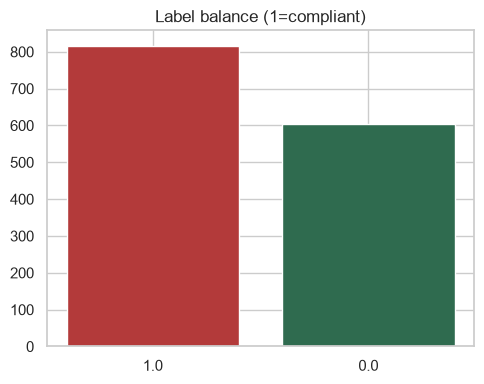

,journey_key,line_key,operator_ref,origin_aimed_departure_time,event_date,hour_of_day,day_of_week,is_peak,delay_minutes,is_compliant,label,fare_proxy,fare_band,has_disruption,disruption_severity_score,primary_disruption_reason,hist_line_noncompliance_rate,hist_line_delay_mean,hist_line_delay_std,hist_line_n_prior
0,ANWE|82A|1013|2026-06-15|3045,82A,ANWE,2026-06-15 05:27:00,2026-06-15,5.0,2.0,0.0,0.183333,1.0,1.0,1.810317,network_default,1.0,3.0,roadClosed,0.625000,62.418750,56.132326,16.0
1,ANWE|79C|5005|0001-01-01|3161,79C,ANWE,2026-07-12 08:15:00,2026-07-12,8.0,1.0,1.0,86.933333,0.0,0.0,1.810317,network_default,0.0,0.0,none,0.395745,8.535319,22.976916,235.0
2,ANWE|P5|4441|2026-07-13|7703,P5,ANWE,2026-07-13 11:00:00,2026-07-13,11.0,2.0,0.0,486.100000,0.0,0.0,1.810317,network_default,0.0,0.0,none,1.000000,167.518750,220.479672,8.0
3,ANWE|X30|1021|2026-07-14|3138,X30,ANWE,2026-07-14 14:42:00,2026-07-14,14.0,3.0,0.0,81.300000,0.0,0.0,1.810317,network_default,0.0,0.0,none,0.357143,12.600952,25.022695,70.0
4,ANWE|82A|1031|2026-06-16|3140,82A,ANWE,2026-06-16 09:57:00,2026-06-16,9.0,3.0,1.0,0.033333,1.0,1.0,1.810317,network_default,0.0,0.0,none,0.324324,13.530330,33.055853,111.0


In [37]:
# Running feature engineering and saving the ML feature table.
fe, pipe = build_feature_table(spark)
n_features = fe.count()
print("Feature rows:", n_features)
fe.groupBy("label").count().show()
fe.write.mode("overwrite").parquet(str(PROCESSED_DIR / "features_journeys.parquet"))

sample = fe.drop("features").limit(20).toPandas()
sample.to_csv(FEATURES_DIR / "feature_sample_preview.csv", index=False)
(FEATURES_DIR / "feature_metadata.json").write_text(
    json.dumps({"n_rows": n_features, "cat_cols": CAT_COLS, "num_cols": NUM_COLS}, indent=2),
    encoding="utf-8",
)
print("Saved features_journeys.parquet")

label_pdf = fe.groupBy("label").count().toPandas()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(label_pdf["label"].astype(str), label_pdf["count"], color=["#b33a3a", "#2f6b4f"])
ax.set_title("Label balance (1=compliant)")
show_and_save(fig, DATA_EXPLORATION_DIR / "07_label_balance.png")
display(sample.head())

# Phase 5 — SQLite


In [38]:
# Saving the cleaned data and model outputs into a SQLite database.

SCHEMA_SQL = """
CREATE TABLE IF NOT EXISTS trips_cleaned (
    journey_key TEXT PRIMARY KEY,
    line_key TEXT,
    operator_ref TEXT,
    origin_aimed_departure_time TEXT,
    event_date TEXT,
    hour_of_day REAL,
    day_of_week REAL,
    is_peak REAL,
    delay_minutes REAL,
    is_compliant INTEGER,
    fare_proxy REAL,
    fare_band TEXT,
    has_disruption INTEGER,
    disruption_severity_score REAL,
    primary_disruption_reason TEXT,
    hist_line_noncompliance_rate REAL,
    hist_line_delay_mean REAL,
    hist_line_delay_std REAL,
    hist_line_n_prior REAL
);

CREATE TABLE IF NOT EXISTS line_reliability (
    line_key TEXT,
    operator_ref TEXT,
    n_journeys INTEGER,
    n_compliant INTEGER,
    avg_delay_minutes REAL,
    std_delay_minutes REAL,
    service_reliability REAL,
    below_85_threshold INTEGER,
    PRIMARY KEY (line_key, operator_ref)
);

CREATE TABLE IF NOT EXISTS model_metrics (
    model_name TEXT PRIMARY KEY,
    accuracy REAL,
    precision_score REAL,
    recall_score REAL,
    f1 REAL,
    roc_auc REAL,
    train_seconds REAL,
    f1_per_second REAL,
    best_params TEXT,
    notes TEXT
);

CREATE TABLE IF NOT EXISTS ml_predictions (
    journey_key TEXT PRIMARY KEY,
    model_name TEXT,
    label INTEGER,
    prediction INTEGER,
    probability_compliant REAL,
    fare_proxy REAL,
    hypothetical_exposure REAL
);

CREATE INDEX IF NOT EXISTS idx_trips_line ON trips_cleaned(line_key);
CREATE INDEX IF NOT EXISTS idx_trips_compliant ON trips_cleaned(is_compliant);
CREATE INDEX IF NOT EXISTS idx_pred_model ON ml_predictions(model_name);
"""

In [39]:
# Creating a connection to the SQLite database.
# The database folder is created automatically if it doesn't exist.
def get_connection(db_path: Path | None = None) -> sqlite3.Connection:
    path = Path(db_path or DB_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    conn = sqlite3.connect(str(path))
    conn.execute("PRAGMA foreign_keys = ON;")
    return conn

In [40]:
# Creating all the required tables before saving any data.
def init_schema(conn: sqlite3.Connection) -> None:
    conn.executescript(SCHEMA_SQL)
    conn.commit()


# Writing multiple rows into the database using parameterised queries.
def executemany_param(
    conn: sqlite3.Connection,
    sql: str,
    rows: Iterable[tuple[Any, ...]],
) -> None:
    conn.executemany(sql, list(rows))
    conn.commit()

In [41]:
# Running a single SQL query with parameters.
def execute_param(
    conn: sqlite3.Connection,
    sql: str,
    params: tuple[Any, ...] = (),
) -> sqlite3.Cursor:
    cur = conn.execute(sql, params)
    conn.commit()
    return cur


# Running a query and returning the matching records.
def fetch_param(
    conn: sqlite3.Connection,
    sql: str,
    params: tuple[Any, ...] = (),
) -> list[tuple]:
    cur = conn.execute(sql, params)
    return cur.fetchall()

In [42]:
# Saving the cleaned journey dataset into the database.
# Replacing the old data each time to keep only the latest version.
def upsert_trips_from_dataframe(conn: sqlite3.Connection, df: pd.DataFrame) -> int:
    cols = [
        "journey_key",
        "line_key",
        "operator_ref",
        "origin_aimed_departure_time",
        "event_date",
        "hour_of_day",
        "day_of_week",
        "is_peak",
        "delay_minutes",
        "is_compliant",
        "fare_proxy",
        "fare_band",
        "has_disruption",
        "disruption_severity_score",
        "primary_disruption_reason",
        "hist_line_noncompliance_rate",
        "hist_line_delay_mean",
        "hist_line_delay_std",
        "hist_line_n_prior",
    ]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"trips df missing columns: {missing}")

    work = df[cols].copy()
    for c in ["origin_aimed_departure_time", "event_date"]:
        work[c] = work[c].astype(str)
    work["is_compliant"] = work["is_compliant"].fillna(0).astype(int)
    work["has_disruption"] = work["has_disruption"].fillna(0).astype(int)

    execute_param(conn, "DELETE FROM trips_cleaned")
    sql = f"""
        INSERT INTO trips_cleaned (
            {", ".join(cols)}
        ) VALUES (
            {", ".join(["?"] * len(cols))}
        )
    """
    rows = [tuple(None if pd.isna(v) else v for v in rec) for rec in work.itertuples(index=False, name=None)]
    executemany_param(conn, sql, rows)
    return len(rows)

In [43]:
# Saving the reliability summary for each bus line.
def upsert_line_reliability(conn: sqlite3.Connection, df: pd.DataFrame) -> int:
    cols = [
        "line_key",
        "operator_ref",
        "n_journeys",
        "n_compliant",
        "avg_delay_minutes",
        "std_delay_minutes",
        "service_reliability",
        "below_85_threshold",
    ]
    work = df[cols].copy()
    execute_param(conn, "DELETE FROM line_reliability")
    sql = f"""
        INSERT INTO line_reliability (
            {", ".join(cols)}
        ) VALUES (
            {", ".join(["?"] * len(cols))}
        )
    """
    rows = [tuple(None if pd.isna(v) else v for v in rec) for rec in work.itertuples(index=False, name=None)]
    executemany_param(conn, sql, rows)
    return len(rows)

In [44]:
# Saving the evaluation results for each machine learning model.
def replace_model_metrics(conn: sqlite3.Connection, rows: list[dict]) -> None:
    execute_param(conn, "DELETE FROM model_metrics")
    sql = """
        INSERT INTO model_metrics (
            model_name, accuracy, precision_score, recall_score, f1, roc_auc,
            train_seconds, f1_per_second, best_params, notes
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """
    payloads = [
        (
            r.get("model_name"),
            r.get("accuracy"),
            r.get("precision_score"),
            r.get("recall_score"),
            r.get("f1"),
            r.get("roc_auc"),
            r.get("train_seconds"),
            r.get("f1_per_second"),
            r.get("best_params"),
            r.get("notes"),
        )
        for r in rows
    ]
    executemany_param(conn, sql, payloads)

In [45]:
# Saving the final model predictions for every journey.
def replace_predictions(conn: sqlite3.Connection, df: pd.DataFrame) -> int:
    cols = [
        "journey_key",
        "model_name",
        "label",
        "prediction",
        "probability_compliant",
        "fare_proxy",
        "hypothetical_exposure",
    ]
    work = df[cols].copy()
    execute_param(conn, "DELETE FROM ml_predictions")
    sql = f"""
        INSERT INTO ml_predictions (
            {", ".join(cols)}
        ) VALUES (
            {", ".join(["?"] * len(cols))}
        )
    """
    rows = [tuple(None if pd.isna(v) else v for v in rec) for rec in work.itertuples(index=False, name=None)]
    executemany_param(conn, sql, rows)
    return len(rows)

In [47]:
# Creating the database and setting up all the required tables.
conn = get_connection(DB_PATH)
init_schema(conn)

# Loading the cleaned journey data and saving it into SQLite.
feat_pdf = pd.read_parquet(PROCESSED_DIR / "features_journeys.parquet")
if "features" in feat_pdf.columns:
    feat_pdf = feat_pdf.drop(columns=["features"])
n_trips = upsert_trips_from_dataframe(conn, feat_pdf)

# Loading the line reliability summary if it has already been created.
rel_path = RELIABILITY_DIR / "reliability_by_line.parquet"
n_rel = 0
if rel_path.exists():
    n_rel = upsert_line_reliability(conn, pd.read_parquet(rel_path))

# Checking how many records were written into each table.
print("DB:", DB_PATH)
print("trips_cleaned:", n_trips, "| line_reliability:", n_rel)

# Displaying a few of the most delayed non-compliant journeys.
print("Sample non-compliant (parameterised):")
for row in fetch_param(
    conn,
    "SELECT line_key, delay_minutes, is_compliant FROM trips_cleaned WHERE is_compliant = ? ORDER BY delay_minutes DESC LIMIT ?",
    (0, 5),
):
    print(" ", row)

# Saving a simple schema diagram to document the database structure.
schema_md = '''
# Database schema
SQLite: `''' + str(DB_PATH) + '''`

Parameterised SQL only (`?` placeholders).

```mermaid
erDiagram
    trips_cleaned ||--o{ ml_predictions : journey_key
    line_reliability ||--o{ trips_cleaned : line_key
    model_metrics ||--o{ ml_predictions : model_name
```
'''
(DB_SCHEMA_DIR / "schema_diagram.md").write_text(schema_md, encoding="utf-8")
conn.close()


# Opening the database again to make sure everything was saved correctly.
conn2 = get_connection(DB_PATH)
for tbl in ["trips_cleaned", "line_reliability"]:
    print(tbl, fetch_param(conn2, f"SELECT COUNT(*) FROM {tbl}")[0][0], "rows")

# Displaying a few sample records from the trips table.
display(pd.read_sql("SELECT journey_key, line_key, delay_minutes, is_compliant FROM trips_cleaned LIMIT 5", conn2))
conn2.close()

DB: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/db/merseyside_reliability_audit.sqlite
trips_cleaned: 1421 | line_reliability: 17
Sample non-compliant (parameterised):
  ('P12', 733.6, 0)
  ('P5', 702.0, 0)
  ('P2', 699.7833333333333, 0)
  ('P5', 608.45, 0)
  ('P14', 603.7333333333333, 0)
trips_cleaned 1421 rows
line_reliability 17 rows


,journey_key,line_key,delay_minutes,is_compliant
0,ANWE|82A|1013|2026-06-15|3045,82A,0.183333,1
1,ANWE|79C|5005|0001-01-01|3161,79C,86.933333,0
2,ANWE|P5|4441|2026-07-13|7703,P5,486.100000,0
3,ANWE|X30|1021|2026-07-14|3138,X30,81.300000,0
4,ANWE|82A|1031|2026-06-16|3140,82A,0.033333,1


# Phase 5 complete
***


# Phase 6 — ML benchmark (Logistic Regression / Random Forest / Gradient Boosted Trees)

In [48]:
LABEL_COL = "label"
FEATURES_COL = "features"

# Calculating the evaluation metrics for each trained model.
def _metrics(pred, train_seconds, model_name, best_params):
    f1 = float(MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1").evaluate(pred))
    acc = float(MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy").evaluate(pred))
    prec = float(MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision").evaluate(pred))
    rec = float(MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall").evaluate(pred))
    try:
        auc = float(BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(pred))
    except Exception:
        auc = float("nan")
    return {
        "model_name": model_name,
        "accuracy": acc,
        "precision_score": prec,
        "recall_score": rec,
        "f1": f1,
        "roc_auc": auc,
        "train_seconds": train_seconds,
        "f1_per_second": (f1 / train_seconds) if train_seconds > 0 else float("nan"),
        "best_params": best_params,
        "notes": "CrossValidator on train; metrics on held-out test",
    }



In [49]:

# Loading the feature dataset that will be used for training the models.
fe2, _ = build_feature_table(spark)
fe2 = fe2.select("journey_key", "line_key", "fare_proxy", LABEL_COL, FEATURES_COL).cache()

print("Rows:", fe2.count())

# Checking how many compliant and non-compliant journeys are available.
fe2.groupBy(LABEL_COL).count().show()

Imputation audit → /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/data_quality/imputation_audit.json
Rows: 1421
+-----+-----+
|label|count|
+-----+-----+
|  1.0|  817|
|  0.0|  604|
+-----+-----+



In [50]:
# Splitting the data into training and testing sets.
train, test = fe2.randomSplit([0.7, 0.3], seed=42)
train, test = train.cache(), test.cache()

print("Train:", train.count(), "Test:", test.count())

Train: 976 Test: 445


In [51]:
results = []

# Training and tuning the Logistic Regression model.
print("\nTraining Logistic Regression...")
lr = LogisticRegression(labelCol=LABEL_COL, featuresCol=FEATURES_COL, maxIter=50)
lr_grid = ParamGridBuilder().addGrid(lr.regParam, [0.01, 0.1]).addGrid(lr.elasticNetParam, [0.0, 0.5]).build()
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_grid,
    evaluator=BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC"),
    numFolds=3,
    parallelism=2,
    seed=42,
)

t0 = time.time()
lr_model = lr_cv.fit(train)
lr_secs = time.time() - t0

lr_pred = lr_model.transform(test)
lr_best = lr_model.bestModel

lr_m = _metrics(
    lr_pred,
    lr_secs,
    "LogisticRegression",
    f"regParam={lr_best.getRegParam()}, elasticNetParam={lr_best.getElasticNetParam()}",
)
results.append(lr_m)
print(lr_m)


Training Logistic Regression...
{'model_name': 'LogisticRegression', 'accuracy': 0.7393258426966293, 'precision_score': 0.7631466968809997, 'recall_score': 0.7393258426966292, 'f1': 0.7205966427520187, 'roc_auc': 0.7942627368071964, 'train_seconds': 21.961963176727295, 'f1_per_second': 0.03281112152649551, 'best_params': 'regParam=0.01, elasticNetParam=0.0', 'notes': 'CrossValidator on train; metrics on held-out test'}


In [52]:
# Training and tuning the Random Forest model.
print("\nTraining Random Forest...")
rf = RandomForestClassifier(labelCol=LABEL_COL, featuresCol=FEATURES_COL, seed=42)
rf_grid = ParamGridBuilder().addGrid(rf.numTrees, [20, 40]).addGrid(rf.maxDepth, [3, 5]).build()
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC"),
    numFolds=3,
    parallelism=2,
    seed=42,
)

t0 = time.time()
rf_model = rf_cv.fit(train)
rf_secs = time.time() - t0

rf_pred = rf_model.transform(test)
rf_best = rf_model.bestModel

rf_m = _metrics(
    rf_pred,
    rf_secs,
    "RandomForest",
    f"numTrees={rf_best.getNumTrees}, maxDepth={rf_best.getMaxDepth()}",
)
results.append(rf_m)
print(rf_m)


Training Random Forest...
{'model_name': 'RandomForest', 'accuracy': 0.7707865168539326, 'precision_score': 0.8056231448043039, 'recall_score': 0.7707865168539325, 'f1': 0.7536350251840371, 'roc_auc': 0.8132902209509596, 'train_seconds': 13.003628015518188, 'f1_per_second': 0.05795575083235762, 'best_params': 'numTrees=40, maxDepth=5', 'notes': 'CrossValidator on train; metrics on held-out test'}


In [53]:
# Training and tuning the Gradient Boosted Trees model.
print("\nTraining GBT...")
gbt = GBTClassifier(labelCol=LABEL_COL, featuresCol=FEATURES_COL, seed=42, maxIter=20)
gbt_grid = ParamGridBuilder().addGrid(gbt.maxDepth, [2, 3]).addGrid(gbt.stepSize, [0.05, 0.1]).build()
gbt_cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=gbt_grid,
    evaluator=BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC"),
    numFolds=3,
    parallelism=2,
    seed=42,
)

t0 = time.time()
gbt_model = gbt_cv.fit(train)
gbt_secs = time.time() - t0

gbt_pred = gbt_model.transform(test)
gbt_best = gbt_model.bestModel

gbt_m = _metrics(
    gbt_pred,
    gbt_secs,
    "GBT",
    f"maxDepth={gbt_best.getMaxDepth()}, stepSize={gbt_best.getStepSize()}",
)
results.append(gbt_m)
print(gbt_m)


Training GBT...
{'model_name': 'GBT', 'accuracy': 0.7707865168539326, 'precision_score': 0.7905191212672714, 'recall_score': 0.7707865168539325, 'f1': 0.7580870317258808, 'roc_auc': 0.8347738672636074, 'train_seconds': 18.897026777267456, 'f1_per_second': 0.040116735858036476, 'best_params': 'maxDepth=3, stepSize=0.1', 'notes': 'CrossValidator on train; metrics on held-out test'}


In [54]:
# Selecting the best model based on F1 score, then ROC-AUC and training efficiency.
best = sorted(
    results,
    key=lambda r: (r["f1"], r.get("roc_auc") or 0.0, r["f1_per_second"]),
    reverse=True,
)[0]

print("\nBEST MODEL:", best["model_name"], "F1=", best["f1"])

model_map = {
    "LogisticRegression": lr_model,
    "RandomForest": rf_model,
    "GBT": gbt_model,
}
best_fitted = model_map[best["model_name"]]

# Saving the model comparison results for later analysis.
cmp = pd.DataFrame(results)
cmp.to_csv(ML_DIR / "model_comparison.csv", index=False)

(ML_DIR / "model_comparison.json").write_text(
    json.dumps(results, indent=2),
    encoding="utf-8",
)

(ML_DIR / "best_model_summary.json").write_text(
    json.dumps(
        {
            "best_model": best,
            "selection_rule": "highest F1, then ROC-AUC, then F1/sec",
            "n_train": train.count(),
            "n_test": test.count(),
        },
        indent=2,
    ),
    encoding="utf-8",
)


BEST MODEL: GBT F1= 0.7580870317258808


526

In [55]:
# Saving some notes about the expected time complexity of each model.
(ML_DIR / "big_o_notes.md").write_text(
    "# Big-O notes\n"
    "- LR ≈ O(k·g·i·n·d)\n"
    "- RF ≈ O(k·g·t·n·d·depth) (parallel trees)\n"
    "- GBT ≈ O(k·g·t·n·d·depth) sequential boosting\n"
    "Efficiency = F1 / training_seconds\n",
    encoding="utf-8",
)

159

In [56]:
# Generating predictions for the full dataset using the best model.
full_pred = best_fitted.transform(fe2)

pred_pdf = (
    full_pred.select(
        "journey_key",
        F.lit(best["model_name"]).alias("model_name"),
        F.col(LABEL_COL).cast("int").alias("label"),
        F.col("prediction").cast("int").alias("prediction"),
        vector_to_array("probability")[1].alias("probability_compliant"),
        "fare_proxy",
    )
    .withColumn(
        "hypothetical_exposure",
        (F.lit(1.0) - F.col("probability_compliant")) * F.col("fare_proxy"),
    )
    .toPandas()
)

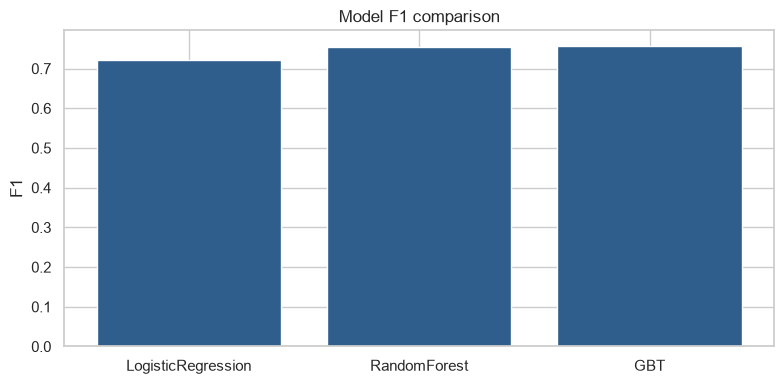

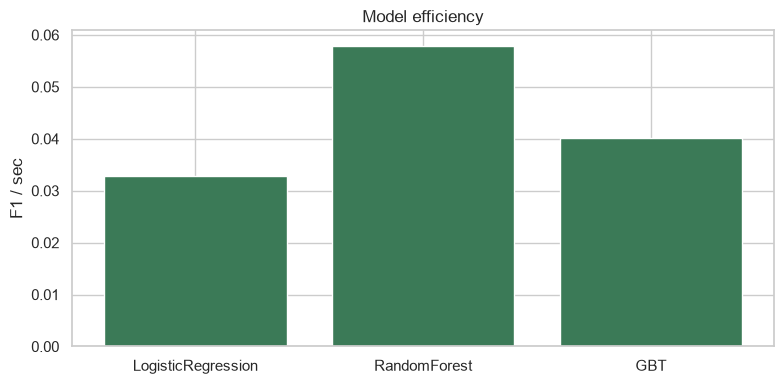

Saved best model + metrics + predictions
           model_name  accuracy        f1   roc_auc  train_seconds  \
0  LogisticRegression  0.739326  0.720597  0.794263      21.961963   
1        RandomForest  0.770787  0.753635  0.813290      13.003628   
2                 GBT  0.770787  0.758087  0.834774      18.897027   

   f1_per_second  
0       0.032811  
1       0.057956  
2       0.040117  
Phase 6 done.


In [57]:
# Comparing the F1 score of all the models.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cmp["model_name"], cmp["f1"], color="#2f5d8c")
ax.set_ylabel("F1")
ax.set_title("Model F1 comparison")
show_and_save(fig, VIS / "model_evaluation" / "model_f1_comparison.png")

# Comparing the efficiency of each model based on training time.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cmp["model_name"], cmp["f1_per_second"], color="#3b7a57")
ax.set_ylabel("F1 / sec")
ax.set_title("Model efficiency")
show_and_save(fig, VIS / "model_evaluation" / "model_efficiency.png")

# Saving the model metrics and predictions into the database.
conn = get_connection(DB_PATH)
init_schema(conn)
replace_model_metrics(conn, results)
replace_predictions(conn, pred_pdf)
conn.close()

# Saving the best trained model so it can be used again later.
models_dir = ML_DIR / "best_model"
models_dir.mkdir(parents=True, exist_ok=True)
best_fitted.bestModel.write().overwrite().save(str(models_dir / best["model_name"]))

print("Saved best model + metrics + predictions")
print(cmp[["model_name", "accuracy", "f1", "roc_auc", "train_seconds", "f1_per_second"]])
print("Phase 6 done.")

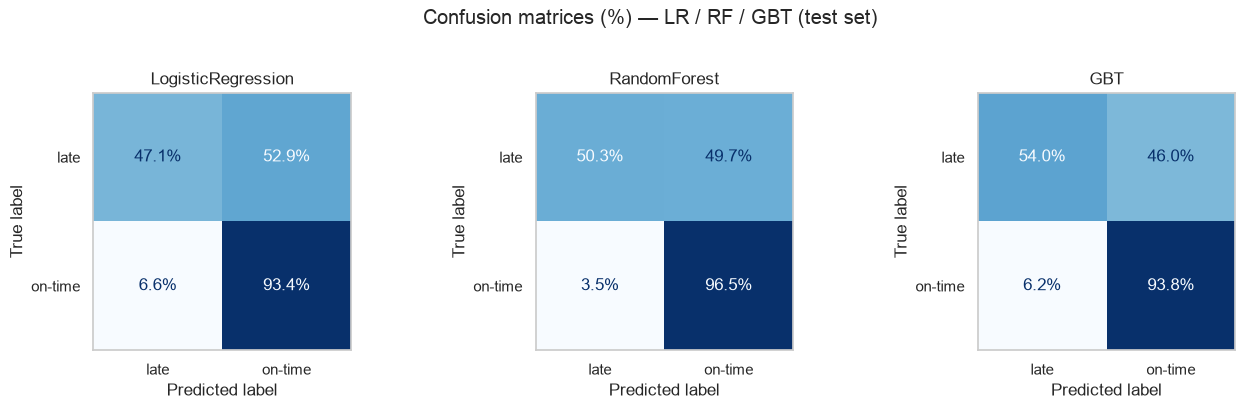

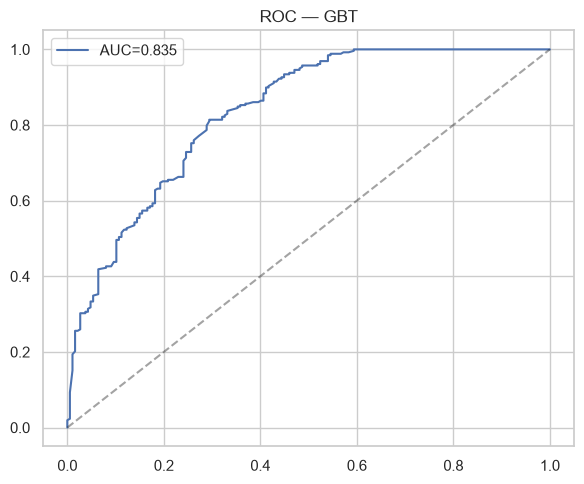

,model_name,f1,roc_auc,train_seconds
0,LogisticRegression,0.720597,0.794263,21.961963
1,RandomForest,0.753635,0.813290,13.003628
2,GBT,0.758087,0.834774,18.897027


Recommended: GBT F1=0.758


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

pred_map = {
    "LogisticRegression": lr_pred,
    "RandomForest": rf_pred,
    "GBT": gbt_pred,
}

# Comparing the confusion matrices for all three models.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred_df) in zip(axes, pred_map.items()):
    pdf = pred_df.select("label", "prediction").toPandas()
    cm = confusion_matrix(
        pdf["label"], pdf["prediction"], labels=[0.0, 1.0], normalize="true"
    )
    ConfusionMatrixDisplay(cm, display_labels=["late", "on-time"]).plot(
        ax=ax, cmap="Blues", values_format=".1%", colorbar=False
    )
    ax.grid(False)
    ax.set_title(name)

fig.suptitle("Confusion matrices (%) — LR / RF / GBT (test set)", y=1.02)
fig.tight_layout()
show_and_save(fig, VIS / "model_evaluation" / "confusion_matrix_all_models.png")

# Plotting the ROC curve for the best-performing model.
best_pred = pred_map[best["model_name"]]
ev = best_pred.select(
    "label",
    "prediction",
    vector_to_array("probability").alias("prob")
).toPandas()

ev["score"] = ev["prob"].apply(lambda a: float(a[1]))

fpr, tpr, _ = roc_curve(ev["label"], ev["score"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.legend()
ax.set_title(f"ROC — {best['model_name']}")

show_and_save(fig, VIS / "model_evaluation" / "roc_auc_curve.png")

# Displaying the final comparison before selecting the recommended model.
display(cmp[["model_name", "f1", "roc_auc", "train_seconds"]])

print(f"Recommended: {best['model_name']} F1={best['f1']:.3f}")

# Phase 6 complete
***


# Phase 7 — Stakeholder exports

`streamlit run streamlit_dashboard.py`


In [59]:
# Loading the trip data together with the model predictions from the database.
conn = get_connection(DB_PATH)
trips_j = pd.read_sql(
    '''SELECT t.*, p.model_name, p.prediction, p.probability_compliant, p.hypothetical_exposure
       FROM trips_cleaned t
       INNER JOIN ml_predictions p ON t.journey_key = p.journey_key''',
    conn,
)

# Loading the service reliability summary for each bus line.
rel = pd.read_sql("SELECT * FROM line_reliability", conn)

In [61]:
# Calculating the probability of a journey being non-compliant.
trips_j["prob_noncompliant"] = 1.0 - trips_j["probability_compliant"].astype(float)
trips_j["hypothetical_exposure"] = trips_j["prob_noncompliant"] * trips_j["fare_proxy"].astype(float)

# Creating some extra fields to compare each line against the 85% benchmark.
rel["service_reliability"] = rel["service_reliability"].astype(float)
rel["gap_to_85"] = SERVICE_RELIABILITY_THRESHOLD - rel["service_reliability"]
rel["status"] = rel["service_reliability"].apply(
    lambda x: "below_85" if x < SERVICE_RELIABILITY_THRESHOLD else "meets_85"
)
rel["near_85"] = (
    (rel["service_reliability"] >= SERVICE_RELIABILITY_THRESHOLD - NEAR_85_BAND)
    & (rel["service_reliability"] < SERVICE_RELIABILITY_THRESHOLD + NEAR_85_BAND)
).astype(int)

In [62]:
# Ranking journeys based on the predicted risk of being non-compliant.
trip_risk = trips_j.sort_values("prob_noncompliant", ascending=False)

# Summarising the results for each bus line.
by_line = (
    trips_j.groupby(["line_key", "operator_ref"], as_index=False)
    .agg(
        n_trips=("journey_key", "count"),
        mean_prob_noncompliant=("prob_noncompliant", "mean"),
        total_hypothetical_exposure=("hypothetical_exposure", "sum"),
        mean_hypothetical_exposure=("hypothetical_exposure", "mean"),
        observed_compliance_rate=("is_compliant", "mean"),
    )
    .merge(
        rel[
            [
                "line_key",
                "operator_ref",
                "service_reliability",
                "below_85_threshold",
                "gap_to_85",
                "status",
                "near_85",
            ]
        ],
        on=["line_key", "operator_ref"],
        how="left",
    )
    .sort_values("total_hypothetical_exposure", ascending=False)
)

# Summarising the risk level for each hour of the day.
by_hour = (
    trips_j.groupby("hour_of_day", as_index=False)
    .agg(
        n_trips=("journey_key", "count"),
        mean_prob_noncompliant=("prob_noncompliant", "mean"),
        total_hypothetical_exposure=("hypothetical_exposure", "sum"),
        observed_compliance_rate=("is_compliant", "mean"),
    )
    .sort_values("hour_of_day")
)

# Creating a summary for every line and hour combination.
by_lh = (
    trips_j.groupby(["line_key", "hour_of_day"], as_index=False)
    .agg(
        n_trips=("journey_key", "count"),
        mean_prob_noncompliant=("prob_noncompliant", "mean"),
        total_hypothetical_exposure=("hypothetical_exposure", "sum"),
    )
)

# Separating lines based on whether they meet the 85% target.
below = rel[rel["below_85_threshold"] == 1].copy()
near = rel[rel["near_85"] == 1].copy()
meets = rel[rel["status"] == "meets_85"].copy()

In [64]:
# Saving all dashboard datasets for Streamlit.
trip_risk.to_csv(DASHBOARD_EXPORTS_DIR / "trip_risk.csv", index=False)
trip_risk.to_parquet(DASHBOARD_EXPORTS_DIR / "trip_risk.parquet", index=False)
by_line.to_csv(DASHBOARD_EXPORTS_DIR / "line_risk_summary.csv", index=False)
by_hour.to_csv(DASHBOARD_EXPORTS_DIR / "hour_risk_summary.csv", index=False)
by_lh.to_csv(DASHBOARD_EXPORTS_DIR / "line_hour_risk.csv", index=False)
below.to_csv(DASHBOARD_EXPORTS_DIR / "lines_below_85.csv", index=False)
near.to_csv(DASHBOARD_EXPORTS_DIR / "lines_near_85.csv", index=False)
meets.to_csv(DASHBOARD_EXPORTS_DIR / "lines_meeting_85.csv", index=False)

In [65]:
# Creating the map files used by the dashboard.
from map_exports import build_map_exports

map_geo_path, map_routes_path = build_map_exports(PROCESSED_DIR, DASHBOARD_EXPORTS_DIR)
print("Map exports:", map_geo_path, map_routes_path)

# Creating the dashboard charts.
fig_dir = VIS / "dashboard_charts"

Map exports: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/dashboard_exports/line_map_geo.csv /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/dashboard_exports/line_map_routes.json


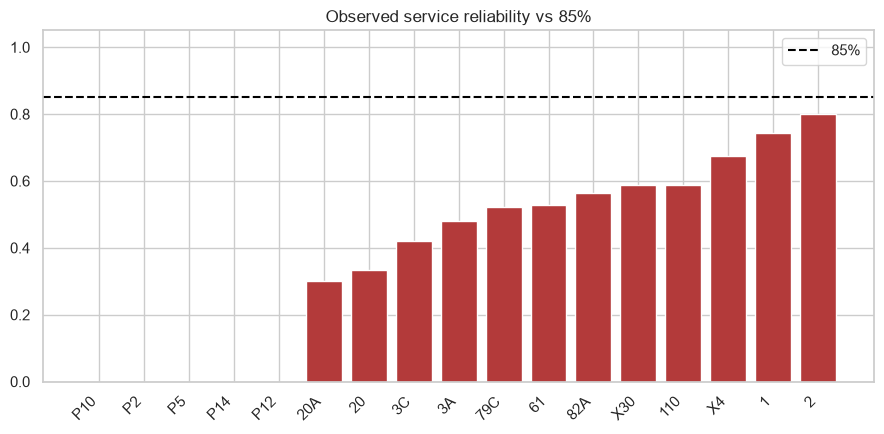

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts/reliability_vs_85.png')

In [66]:
# Comparing each line against the 85% reliability target.
plot_rel = rel.sort_values("service_reliability")
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [
    "#b33a3a" if x < SERVICE_RELIABILITY_THRESHOLD else "#2f6b4f"
    for x in plot_rel["service_reliability"]
]
ax.bar(plot_rel["line_key"].astype(str), plot_rel["service_reliability"], color=colors)
ax.axhline(SERVICE_RELIABILITY_THRESHOLD, color="black", linestyle="--", label="85%")
ax.set_ylim(0, 1.05)
ax.set_title("Observed service reliability vs 85%")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
show_and_save(fig, fig_dir / "reliability_vs_85.png")

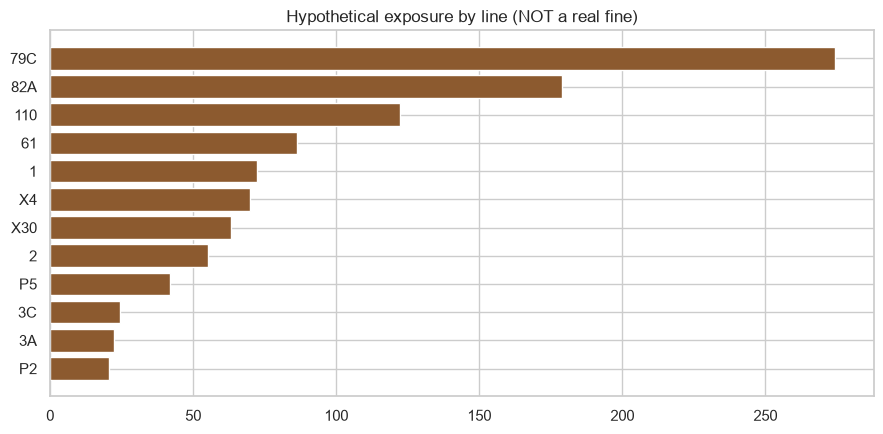

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts/hypothetical_exposure_by_line.png')

In [67]:
# Showing which bus lines have the highest predicted exposure.
top = by_line.head(12).sort_values("total_hypothetical_exposure")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top["line_key"].astype(str), top["total_hypothetical_exposure"], color="#8c5a2f")
ax.set_title("Hypothetical exposure by line (NOT a real fine)")
fig.tight_layout()
show_and_save(fig, fig_dir / "hypothetical_exposure_by_line.png")

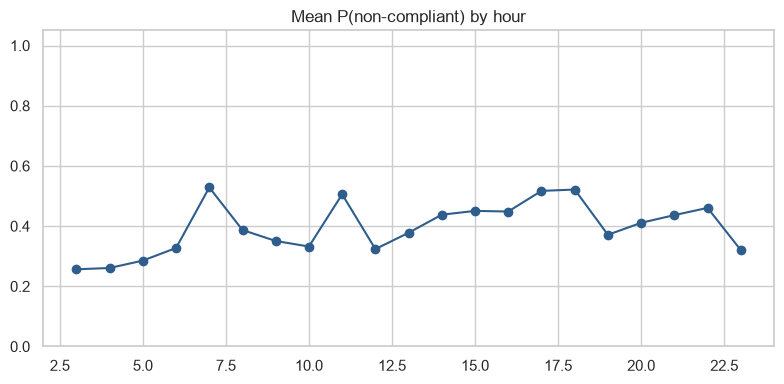

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts/prob_noncompliant_by_hour.png')

In [68]:
# Comparing non-compliance risk throughout the day.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_hour["hour_of_day"], by_hour["mean_prob_noncompliant"], marker="o", color="#2f5d8c")
ax.set_ylim(0, 1.05)
ax.set_title("Mean P(non-compliant) by hour")
fig.tight_layout()
show_and_save(fig, fig_dir / "prob_noncompliant_by_hour.png")

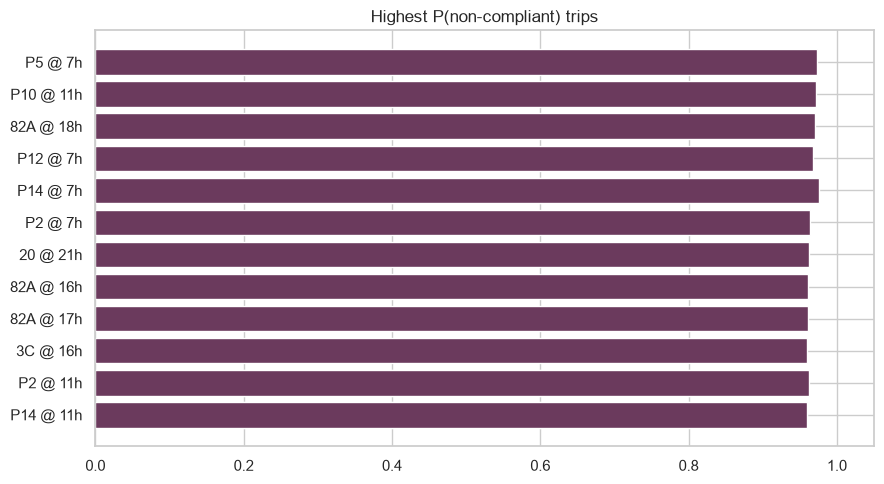

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts/top_trip_noncompliance_prob.png')

In [69]:
# Showing the journeys with the highest predicted risk.
top_trips = trip_risk.head(15).iloc[::-1]
labels = (
    top_trips["line_key"].astype(str)
    + " @ "
    + top_trips["hour_of_day"].fillna(0).astype(int).astype(str)
    + "h"
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, top_trips["prob_noncompliant"], color="#6b3a5d")
ax.set_xlim(0, 1.05)
ax.set_title("Highest P(non-compliant) trips")
fig.tight_layout()
show_and_save(fig, fig_dir / "top_trip_noncompliance_prob.png")

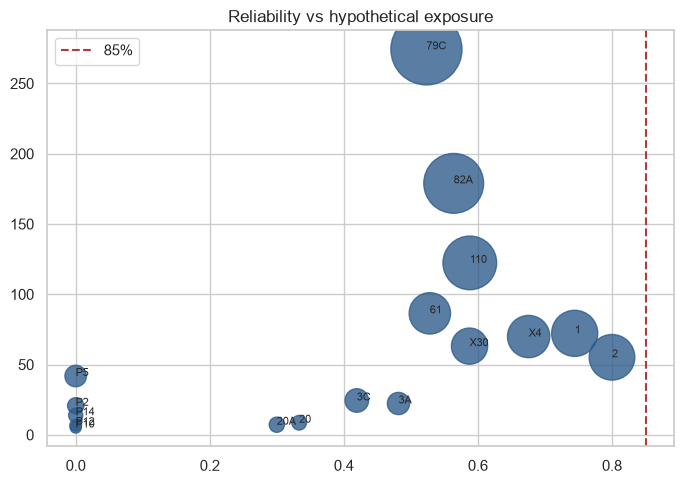

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts/reliability_vs_exposure.png')

In [70]:
# Comparing service reliability with predicted exposure.
m = by_line.dropna(subset=["service_reliability"])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    m["service_reliability"],
    m["total_hypothetical_exposure"],
    s=40 + 8 * m["n_trips"],
    c="#2f5d8c",
    alpha=0.8,
)
for _, r in m.iterrows():
    ax.annotate(
        str(r["line_key"]),
        (r["service_reliability"], r["total_hypothetical_exposure"]),
        fontsize=8,
    )
ax.axvline(
    SERVICE_RELIABILITY_THRESHOLD,
    color="#b33a3a",
    linestyle="--",
    label="85%",
)
ax.set_title("Reliability vs hypothetical exposure")
ax.legend()
fig.tight_layout()
show_and_save(fig, fig_dir / "reliability_vs_exposure.png")

In [71]:
# Creating a short summary for stakeholders.
brief = [
    f"- Trips scored: **{len(trip_risk)}**",
    f"- Lines below 85%: **{len(below)}**",
    f"- Total hypothetical exposure: **{by_line['total_hypothetical_exposure'].sum():.2f}**",
    f"- Mean P(non-compliant): **{trip_risk['prob_noncompliant'].mean():.3f}**",
    "",
    "## Lines below 85%",
]
for _, r in below.sort_values("service_reliability").iterrows():
    brief.append(
        f"- Line **{r['line_key']}**: reliability={r['service_reliability']:.1%}, n={int(r['n_journeys'])}"
    )

(DASHBOARD_EXPORTS_DIR / "stakeholder_brief.md").write_text(
    "\n".join(brief),
    encoding="utf-8",
)

815

In [72]:
# Copying the charts into the final outputs folder.
dst = OUT / "visuals"
dst.mkdir(parents=True, exist_ok=True)

for name in VIS_EXPORT_NAMES:
    src = VIS / name
    if not src.is_dir():
        continue
    target = dst / name
    if target.exists():
        shutil.rmtree(target)
    shutil.copytree(src, target)

for name in _LEGACY_DIR_NAMES:
    legacy = dst / name
    if legacy.is_dir():
        shutil.rmtree(legacy)

print("Total hypothetical exposure:", round(by_line["total_hypothetical_exposure"].sum(), 2))
print("Dashboard charts saved to", fig_dir)

conn.close()

Total hypothetical exposure: 1073.29
Dashboard charts saved to /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/dashboard_charts


In [73]:
# Loading the analytical journey dataset for SQL queries used in the report.
spark.read.parquet(str(PROCESSED_DIR / "analytical_journeys.parquet")).createOrReplaceTempView("journeys")

# Displaying a few sample records from the final dataset.
spark.sql("SELECT delay_minutes, is_compliant FROM journeys LIMIT 10").show()

spark.sql("""
  SELECT journey_key, origin_aimed_departure_time, delay_minutes
  FROM journeys LIMIT 5
""").show(truncate=False)

# Showing the compliance status and delay values for sample journeys.
spark.sql("""
  SELECT
    line_key,
    ROUND(delay_minutes, 2) AS delay_minutes,
    CAST(is_compliant AS INT) AS is_compliant
  FROM journeys
  LIMIT 10
""").show()

# Checking the fare and disruption information after feature engineering.
spark.sql("""
  SELECT line_key, has_txc_line_match, fare_proxy_source, fare_proxy, has_disruption
  FROM journeys
  LIMIT 12
""").show(truncate=False)

+--------------------+------------+
|       delay_minutes|is_compliant|
+--------------------+------------+
|-0.16666666666666666|           1|
| -0.6166666666666667|           1|
|                2.15|           0|
|-0.13333333333333333|           1|
|0.016666666666666666|           1|
|  0.5833333333333334|           1|
|                10.4|           0|
|               -0.05|           1|
|                 0.0|           1|
|  2.3833333333333333|           0|
+--------------------+------------+

+-----------------------------+---------------------------+--------------------+
|journey_key                  |origin_aimed_departure_time|delay_minutes       |
+-----------------------------+---------------------------+--------------------+
|ANWE|110|1001|2026-06-16|3020|2026-06-16 03:57:00        |-0.16666666666666666|
|ANWE|110|1003|2026-06-15|3177|2026-06-15 04:20:00        |-0.6166666666666667 |
|ANWE|110|1007|2026-06-15|3018|2026-06-15 05:30:00        |2.15                |
|ANWE|110

In [74]:
# Loading the feature dataset used for machine learning.
fe = spark.read.parquet(str(PROCESSED_DIR / "features_journeys.parquet"))

print("Schema (note: features = VectorUDT from VectorAssembler):")
fe.select("journey_key", "line_key", "label", "features").printSchema()

# Displaying a few examples of the assembled feature vectors.
print("\nSample ML rows (assembled feature vectors):")
fe.select("journey_key", "label", "features").show(5, truncate=60)

# Checking the size of the feature vector.
print("\nFeature vector size (first row):")
from pyspark.ml.functions import vector_to_array

fe.select(vector_to_array("features").alias("feat_arr")).limit(1).selectExpr(
    "size(feat_arr) AS feature_dim"
).show()


# Showing the hyperparameter grids used during model tuning.
import pandas as pd
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder

lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=50)
print(
    "LR grid size:",
    len(
        ParamGridBuilder()
        .addGrid(lr.regParam, [0.01, 0.1])
        .addGrid(lr.elasticNetParam, [0.0, 0.5])
        .build()
    ),
)

rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)
print(
    "RF grid size:",
    len(
        ParamGridBuilder()
        .addGrid(rf.numTrees, [20, 40])
        .addGrid(rf.maxDepth, [3, 5])
        .build()
    ),
)

gbt = GBTClassifier(labelCol="label", featuresCol="features", seed=42, maxIter=20)
print(
    "GBT grid size:",
    len(
        ParamGridBuilder()
        .addGrid(gbt.maxDepth, [2, 3])
        .addGrid(gbt.stepSize, [0.05, 0.1])
        .build()
    ),
)

# Displaying the best parameters selected by CrossValidator.
print("\nBest params found by CrossValidator (from saved results):")
print(pd.read_csv(ML_DIR / "model_comparison.csv")[["model_name", "best_params", "f1", "roc_auc"]])

Schema (note: features = VectorUDT from VectorAssembler):
root
 |-- journey_key: string (nullable = true)
 |-- line_key: string (nullable = true)
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)


Sample ML rows (assembled feature vectors):
+-----------------------------+-----+------------------------------------------------------------+
|                  journey_key|label|                                                    features|
+-----------------------------+-----+------------------------------------------------------------+
| ANWE|X4|1004|2026-06-15|2793|  0.0|(65,[0,1,3,4,7,9,10,11,12,15,17,19,20,21,22,23,24,30,44,4...|
|ANWE|82A|1062|2026-06-16|3078|  1.0|(65,[0,1,3,4,7,9,17,19,20,21,22,23,24,26,44,46,48,50,52,6...|
|ANWE|82A|1005|2026-06-16|3138|  1.0|(65,[0,1,3,4,7,9,10,11,12,13,15,17,19,20,21,22,23,24,26,4...|
|ANWE|79C|1063|0001-01-01|3078|  0.0|(65,[0,1,3,7,9,17,19,20,21,22,23,24,25,43,46,48,50,52,60]...|
|ANWE|79C|1066|2026-06-16|3077|  0.0|(

Imputation audit → /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/data_quality/imputation_audit.json
Test rows: 445
Best model: GBT | saved ROC-AUC: 0.8348
LogisticRegression: sklearn AUC=0.7943 | Spark AUC=0.7943
RandomForest: sklearn AUC=0.8133 | Spark AUC=0.8133
GBT: sklearn AUC=0.8348 | Spark AUC=0.8348


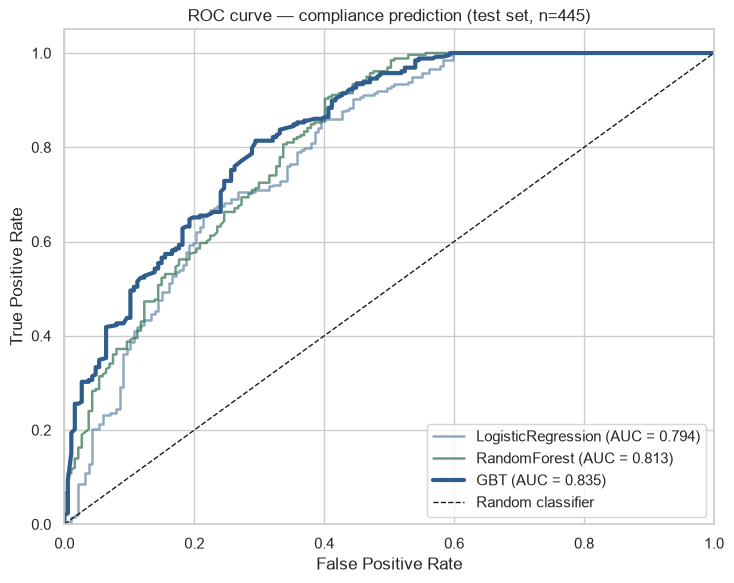

Saved: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/model_evaluation/roc_auc_curve.png
Saved: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/visuals/model_evaluation/roc_auc_curve.png


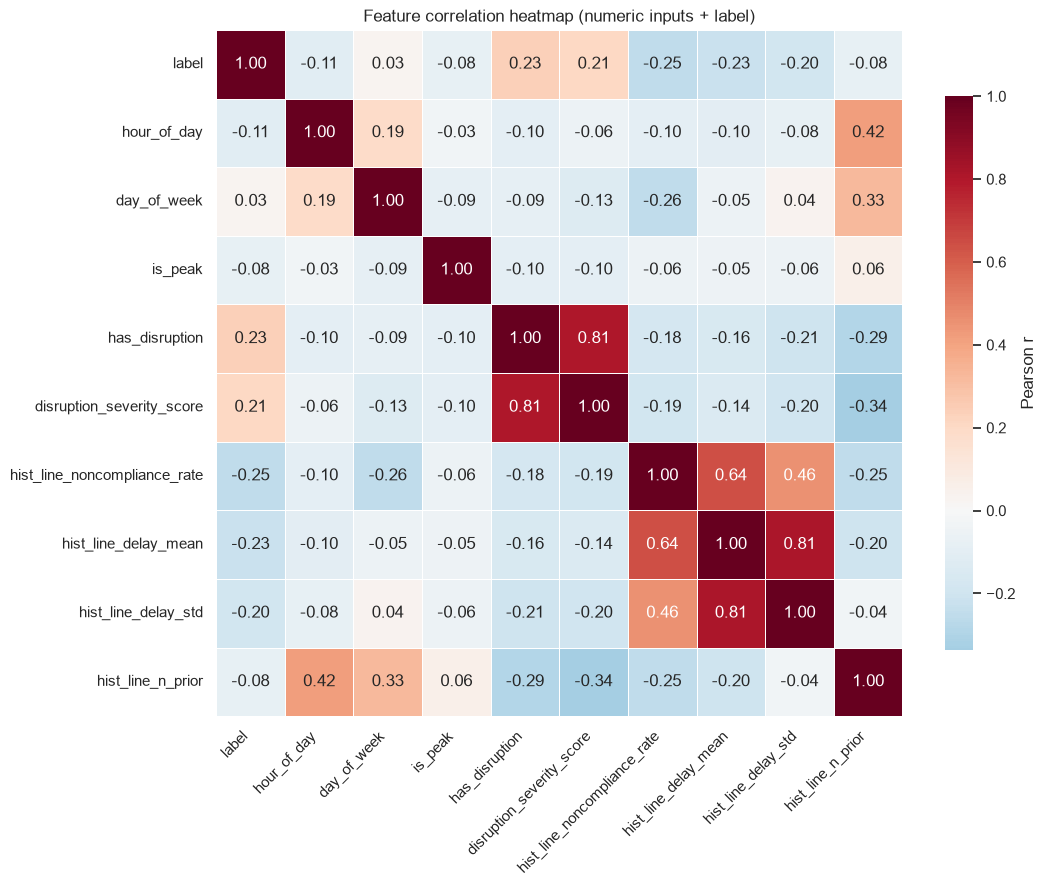

,corr_with_label
label,1.000000
hist_line_noncompliance_rate,-0.253139
has_disruption,0.234701
hist_line_delay_mean,-0.226230
disruption_severity_score,0.207797
hist_line_delay_std,-0.195232
hour_of_day,-0.113145
is_peak,-0.084490
hist_line_n_prior,-0.076942
day_of_week,0.033453


In [75]:
# Loading the test dataset to recreate the ROC curve.
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml.classification import (
    GBTClassificationModel,
    RandomForestClassificationModel,
    LogisticRegressionModel,
)

LABEL_COL = "label"
FIG_DIR = VIS / "model_evaluation"
FIG_DIR.mkdir(parents=True, exist_ok=True)
(OUT / "visuals" / "model_evaluation").mkdir(parents=True, exist_ok=True)

fe2, _ = build_feature_table(spark)
fe2 = fe2.select("journey_key", "line_key", "fare_proxy", LABEL_COL, "features").cache()
train, test = fe2.randomSplit([0.7, 0.3], seed=42)
test = test.cache()

print("Test rows:", test.count())

# Loading the details of the best-performing model.
summary = json.loads((ML_DIR / "best_model_summary.json").read_text())
best_name = summary["best_model"]["model_name"]
best_auc_saved = summary["best_model"]["roc_auc"]

print("Best model:", best_name, "| saved ROC-AUC:", round(best_auc_saved, 4))

MODEL_LOADERS = {
    "LogisticRegression": LogisticRegressionModel,
    "RandomForest": RandomForestClassificationModel,
    "GBT": GBTClassificationModel,
}

# Converting Spark predictions into a pandas DataFrame for plotting.
def predictions_to_pandas(pred_df):
    return (
        pred_df.select(
            F.col(LABEL_COL).cast("double").alias("y_true"),
            vector_to_array("probability")[1].alias("y_score"),
        )
        .toPandas()
    )

# Calculating the ROC-AUC score using Spark.
def spark_auc(pred_df):
    return float(
        BinaryClassificationEvaluator(
            labelCol=LABEL_COL,
            rawPredictionCol="rawPrediction",
            metricName="areaUnderROC",
        ).evaluate(pred_df)
    )

# Reusing the trained models if available, otherwise loading the saved model.
pred_frames = {}

if all(name in globals() for name in ("lr_model", "rf_model", "gbt_model")):
    pred_frames = {
        "LogisticRegression": lr_model.transform(test),
        "RandomForest": rf_model.transform(test),
        "GBT": gbt_model.transform(test),
    }
else:
    model_path = ML_DIR / "best_model" / best_name
    loaded = MODEL_LOADERS[best_name].load(str(model_path))
    pred_frames = {best_name: loaded.transform(test)}

# Calculating the ROC curve for each available model.
curve_data = []

for model_name, pred in pred_frames.items():
    pdf = predictions_to_pandas(pred)
    fpr, tpr, _ = roc_curve(pdf["y_true"], pdf["y_score"])
    roc_auc = auc(fpr, tpr)
    spark_auc_val = spark_auc(pred)

    curve_data.append((model_name, fpr, tpr, roc_auc, spark_auc_val))
    print(f"{model_name}: sklearn AUC={roc_auc:.4f} | Spark AUC={spark_auc_val:.4f}")

# Plotting the ROC curves.
fig, ax = plt.subplots(figsize=(7.5, 6))

colors = {
    "LogisticRegression": "#6b8cae",
    "RandomForest": "#3b7a57",
    "GBT": "#2f5d8c",
}

for model_name, fpr, tpr, roc_auc, _ in curve_data:
    lw = 3 if model_name == best_name else 1.8
    alpha = 1.0 if model_name == best_name else 0.75

    ax.plot(
        fpr,
        tpr,
        color=colors.get(model_name, "#444444"),
        lw=lw,
        alpha=alpha,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC curve — compliance prediction (test set, n={test.count()})")
ax.legend(loc="lower right")
fig.tight_layout()

out_png = FIG_DIR / "roc_auc_curve.png"
out_png2 = OUT / "visuals" / "model_evaluation" / "roc_auc_curve.png"

show_and_save(fig, out_png)
shutil.copy2(out_png, out_png2)

print("Saved:", out_png)
print("Saved:", out_png2)

# Creating a correlation heatmap for the numeric features.
corr_cols = [
    "label",
    "hour_of_day",
    "day_of_week",
    "is_peak",
    "n_obs",
    "has_disruption",
    "disruption_severity_score",
    "scheduled_trip_minutes",
    "hist_line_noncompliance_rate",
    "hist_line_delay_mean",
    "hist_line_delay_std",
    "hist_line_n_prior",
    "has_txc_line_match",
    "has_fare_match",
    "fare_imputed",
]

fe_pdf = pd.read_parquet(PROCESSED_DIR / "features_journeys.parquet")
available = [c for c in corr_cols if c in fe_pdf.columns]
corr = fe_pdf[available].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)

ax.set_title("Feature correlation heatmap (numeric inputs + label)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()

show_and_save(fig, VIS / "model_evaluation" / "feature_correlation_heatmap.png")

# Displaying how strongly each feature is correlated with the target label.
display(
    corr["label"]
    .sort_values(key=abs, ascending=False)
    .to_frame("corr_with_label")
)